# Exploración y análisis inicial - Ventas de lácteos 2024

Este notebook realiza un Análisis Exploratorio de Datos (EDA) del histórico de ventas proporcionado por la empresa distribuidora. El objetivo es comprender la estructura, calidad y comportamiento temporal del dataset para preparar el terreno antes de entrenar un modelo predictivo capaz de estimar cuántas unidades debería pedir la empresa el próximo mes, desglosadas por categoría → producto → presentación.

### 1. Importación de bibliotecas y carga de datos

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [2]:
ruta = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'dataset_ventas_lacteos_2024.csv')
df = pd.read_csv(ruta)
display(df.head())

,ID Orden,Fecha,Nombre del vendedor,Nombre del supermercado,Representante de compras,Estado,Ciudad,Categoría,Producto,Presentación,Precio unitario (USD),Cantidad comprada,Valor total (USD),Forma de pago
0,1,11/03/2024,Zeller Sophie,Exquisite Foods Market,Rogers Harper,California,San Diego,Quesos,Queso en lonchas,Paquete 200g,3.80,543,2063.40,Tarjeta de crédito
1,2,26/07/2024,Smith Noah,The Food Barn,Tremblay Ana,Florida,Tampa,Otros,Suero de leche,Botella 1L,2.00,334,668.00,Tarjeta de débito
2,3,12/01/2024,Zeller Sophie,The Grocery Store,McBride Evelyn,California,San Diego,Quesos,Queso blanco,Bloque 500g,5.00,73,365.00,Tarjeta de débito
3,4,03/06/2024,Williams Chloe,Select Market,Bélanger Theodore,Nueva York,New York City,Yogur,Kumis,Botella 1L,2.50,658,1645.00,Efectivo
4,5,04/11/2024,Davis Olivia,Super Everything,Fraser Michael,California,San Francisco,Mantequilla,Mantequilla clarificada (ghee),Frasco 300ml,5.75,667,3835.25,PayPal


### 2. Entendiendo el dataset

#### 2.1 Información estructural

In [3]:
print("Nº de filas: ", df.shape[0])
print("Nº de columnas: ", df.shape[1])

Nº de filas:  10000
Nº de columnas:  14


In [4]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
ID Orden                      int64
Fecha                        object
Nombre del vendedor          object
Nombre del supermercado      object
Representante de compras     object
Estado                       object
Ciudad                       object
Categoría                    object
Producto                     object
Presentación                 object
Precio unitario (USD)       float64
Cantidad comprada             int64
Valor total (USD)           float64
Forma de pago                object
dtype: object


La única observación que se puede hacer de momento es que el campo **Fecha** debería pasarse a tipo `datetime`. El resto de columnas de tipo object deberían convertirse a tipo `string`.

Por lo que podemos apreciar, para nuestro modelo predictivo, la variable objetivo será la variable **Cantidad comprada**.

#### 2.2 Calidad de los datos

No hay valores nulos en el dataset

In [5]:
print("\nValores nulos por columna:")
print(df.isna().sum())


Valores nulos por columna:
ID Orden                    0
Fecha                       0
Nombre del vendedor         0
Nombre del supermercado     0
Representante de compras    0
Estado                      0
Ciudad                      0
Categoría                   0
Producto                    0
Presentación                0
Precio unitario (USD)       0
Cantidad comprada           0
Valor total (USD)           0
Forma de pago               0
dtype: int64


Tampoco tenemos columnas donde todos los valores sean iguales

In [6]:
zero_var = df.columns[df.nunique() <= 1]
zero_var

Index([], dtype='object')

No existen filas duplicadas

In [7]:
(df.duplicated().sum() / len(df)) * 100

np.float64(0.0)

Y no tenemos valores negativos en columnas que no deberían tenerlos

In [8]:
cols_no_neg = ['Precio unitario (USD)', 'Cantidad comprada', 'Valor total (USD)']

ilegal_neg = {col: df[df[col] < 0][col] for col in cols_no_neg}
ilegal_neg


{'Precio unitario (USD)': Series([], Name: Precio unitario (USD), dtype: float64),
 'Cantidad comprada': Series([], Name: Cantidad comprada, dtype: int64),
 'Valor total (USD)': Series([], Name: Valor total (USD), dtype: float64)}

#### 2.3 Corrección tipo de datos

Vamos a realizar los cambios mencionados en el apartado 2.1

In [9]:
# Convertir Fecha a datetime (formato dd/mm/yyyy)
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%Y")

Aprovechando la conversión de `Fecha` a datetime, extraemos el año y el mes 
como columnas independientes, y creamos `Fecha_mes` con el primer día de cada 
mes para facilitar la agregación mensual que necesitaremos más adelante.

In [10]:
# Crear columnas de año, mes y una fecha "primer día de mes" para agregación mensual
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month
df["Fecha_mes"] = df["Fecha"].dt.to_period("M").dt.to_timestamp()

In [11]:
cols_texto = ["Categoría", "Producto", "Presentación"]

df[cols_texto] = df[cols_texto].astype("string")

### 3. Análisis Univariante

#### 3.1 Variables numéricas

In [12]:
df_describe = df[["Precio unitario (USD)", "Cantidad comprada", "Valor total (USD)"]].describe()
display(df_describe)

,Precio unitario (USD),Cantidad comprada,Valor total (USD)
count,10000.000000,10000.000000,10000.000000
mean,3.249372,498.720600,1620.502492
std,1.592033,286.615413,1311.470311
min,0.650000,10.000000,15.000000
25%,2.000000,251.000000,588.000000
50%,3.000000,493.000000,1250.000000
75%,4.200000,746.250000,2334.000000
max,6.250000,1000.000000,6237.500000


Observaciones:

- Precio unitario (USD)

    Distribución relativamente amplia: oscila entre 0.65 y 6.25, lo cual es normal en productos de alimentación congelada donde hay diferentes presentaciones o categorías.

    La mediana (3.0) está muy cerca de la media → no hay una asimetría fuerte.

    No hay valores negativos ni sospechosamente altos → no parecen haber errores de registro.

- Cantidad comprada

    La mediana (493) es muy cercana a la media (498) → la distribución no está sesgada.

    El mínimo es 10, claramente diferente del resto → probablemente representa pedidos muy pequeños.

    El máximo está en 1000, lo cual suena razonable para compras "por caja múltiple" típicas en mayoristas.

- Valor total (USD)

    Alta dispersión: El rango de valores va desde pedidos de 15 USD hasta pedidos de más de 6000 USD.

    La mediana (1236) está por debajo de la media (1613) → cola derecha (hay pedidos grandes que empujan la media hacia arriba).

    Esto es normal: algunos clientes compran a granel (hostelería, supermercados), mientras otros compran menos.

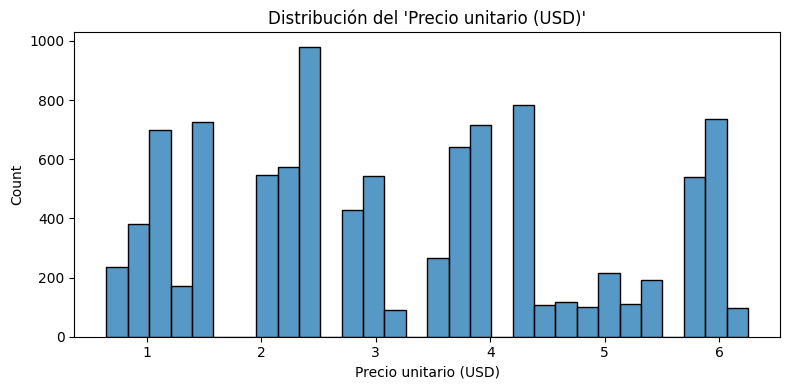

In [13]:
# Distribución del valor total
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Precio unitario (USD)"], bins=30, ax=ax)
ax.set_title("Distribución del 'Precio unitario (USD)'")
ax.set_xlabel("Precio unitario (USD)")
plt.tight_layout()
plt.show()

La distribución del Precio unitario muestra una elevada variabilidad, con valores que oscilan aproximadamente entre 0,8 USD y más de 6 USD, lo que indica que no existe un precio fijo y que el dataset contiene productos de distintas gamas. La forma multimodal del histograma revela varios grupos bien diferenciados de precios, probablemente asociados a diferentes tipos de producto o presentación

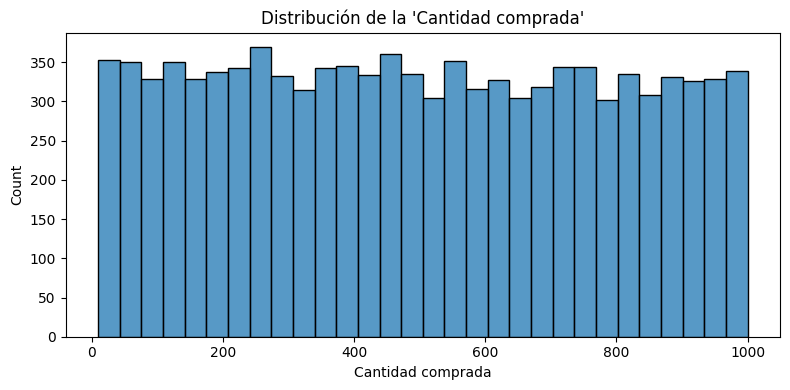

In [14]:
# Distribución de cantidad comprada
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Cantidad comprada"], bins=30, ax=ax)
ax.set_title("Distribución de la 'Cantidad comprada'")
ax.set_xlabel("Cantidad comprada")
plt.tight_layout()
plt.show()

El histograma muestra una forma casi rectangular, con barras muy similares en altura, desde cantidades pequeñas hasta cantidades grandes. Algo poco común en datos de ventas.

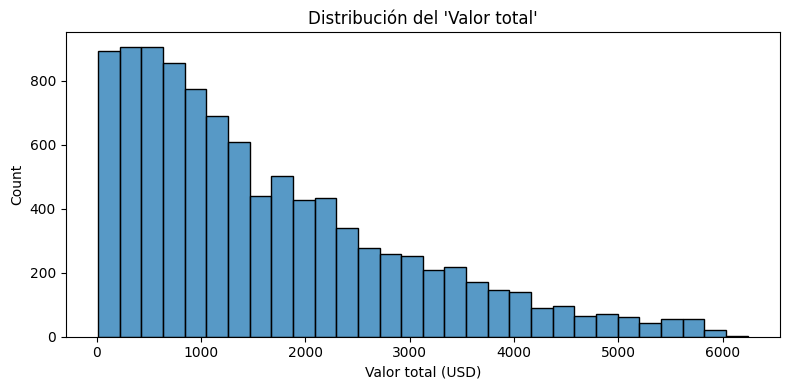

In [15]:
# Distribución del valor total
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Valor total (USD)"], bins=30, ax=ax)
ax.set_title("Distribución del 'Valor total'")
ax.set_xlabel("Valor total (USD)")
plt.tight_layout()
plt.show()

- cola larga hacia la derecha

- acumulación fuerte en los valores pequeños

- decrecimiento exponencial conforme aumenta el importe

Los pequeños clientes compran mucho más a menudo que los grandes compradores.

#### 3.2 Variables categóricas

In [16]:
print("Nº de categorías:", df["Categoría"].nunique())
print("Nº de productos:", df["Producto"].nunique())
print("Nº de presentaciones:", df["Presentación"].nunique())

Nº de categorías: 6
Nº de productos: 39
Nº de presentaciones: 28


In [17]:
print("\nFrecuencia de los valores de la variable 'Categoría':")
display(df["Categoría"].value_counts())



Frecuencia de los valores de la variable 'Categoría':


Categoría
Mantequilla    1712
Leche          1691
Otros          1677
Quesos         1659
Yogur          1640
Cremas         1621
Name: count, dtype: Int64

Vemos que en el conjunto de datos no hay categorías "raras" o poco representadas

In [18]:
raras = df['Categoría'].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras


Series([], Name: proportion, dtype: Float64)

Para saber cuán diversas son las categorías de productos lácteos en el dataset calculamos la entropía, de esta forma podemos medir qué tan diversa o uniforme es la distribución de las categorías de esta columna. Para ello se usará la siguiente fórmula:

$$H = -\sum_{i=1}^{n} p_i \cdot \log_2(p_i)$$

- Entropía alta → las categorías están distribuidas de forma muy uniforme, hay mucha variedad.
- Entropía baja → pocas categorías dominan, hay poca variedad.
- Entropía = 0 → todos los valores son de la misma categoría.

In [19]:
def entropy(col):
    proportions = col.value_counts(normalize=True)
    return -np.sum(proportions * np.log2(proportions))

entropia_categoria = entropy(df['Categoría'])
entropia_categoria

np.float64(2.5847196477592393)

El valor máximo posible de entropía depende del número de categorías únicas.
Para `n` categorías, la entropía máxima sería $\log_2(n)$.

Como tenemos 6 categorías, la entropía máxima sería log₂(6) ≈ 2.58 bits, que coincide con nuestro resultado. Por tanto, la columna   `Categoria` tiene distribución perfectamente uniforme.

Hagamos el mismo estudio para la coluna `Producto`.

In [20]:
print("\nFrecuencia de cada tipo de 'Producto':")
display(df["Producto"].value_counts())


Frecuencia de cada tipo de 'Producto':


Producto
Mantequilla con sal               591
Mantequilla sin sal               581
Mantequilla clarificada (ghee)    540
Suero de leche                    446
Dulce de leche                    435
Yogur griego                      434
Queso crema                       427
Yogur con frutas                  417
Cuajada                           404
Yogur natural                     402
Crema agria                       401
Crema de leche                    398
Crema batida                      395
Helado                            392
Kumis                             387
Leche entera                      203
Leche saborizada                  201
Leche en polvo                    194
Leche condensada                  192
Bebidas lácteas                   189
Leche descremada                  188
Leche deslactosada                182
Leche evaporada                   171
Leche semidescremada              171
Queso ricota                      126
Queso mozzarella                  125
Que

Hay 3 productos con presencia muy baja en el dataset, todos por debajo del 1%: Queso azul roquefort (0.98%), Queso blanco (0.97%) y Queso para untar (0.91%). Son productos que se venden muy poco en comparación con el resto.

In [21]:
raras = df['Producto'].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras


Producto
Queso azul roquefort    0.0098
Queso blanco            0.0097
Queso para untar        0.0091
Name: proportion, dtype: Float64

El valor de 5.03 bits es muy cercano al máximo teórico para 39 categorías, que sería log₂(39) ≈ 5.29 bits. Esto indica que, a pesar de los 3 productos minoritarios detectados, la distribución general es bastante uniforme, es decir, la mayoría de los 39 productos tienen una presencia similar en el dataset y no hay un producto que domine de forma clara.

In [22]:
entropia_producto = entropy(df['Producto'])
entropia_producto

np.float64(5.025554978935216)

In [23]:
print("\nFrecuencia de las combinaciones Producto + Presentación:")
display(
    df.groupby(["Producto", "Presentación"])["ID Orden"]
    .count()
    .sort_values(ascending=False)
)


Frecuencia de las combinaciones Producto + Presentación:


Producto                        Presentación    
Mantequilla con sal             Paquete 454g        591
Mantequilla sin sal             Paquete 454g        581
Mantequilla clarificada (ghee)  Frasco 300ml        540
Suero de leche                  Botella 1L          446
Dulce de leche                  Frasco 250g         435
Yogur griego                    Individual          434
Queso crema                     Tarrina 250g        427
Yogur con frutas                Individual          417
Cuajada                         Envase 250g         404
Crema agria                     Tarrina 200g        401
Crema de leche                  Cartón 946ml        398
Crema batida                    Spray 250ml         395
Kumis                           Botella 1L          387
Yogur natural                   Individual          207
Helado                          Tarrina 500ml       201
Yogur natural                   Familiar 1L         195
Leche condensada                Lata 397g           192

 Hay 12 combinaciones de Producto-Presentación que aparecen menos del 1% de las veces. Destacan productos como Leche entera, que aparece en 3 presentaciones poco frecuentes (Galón, Individual y Litro), lo que podría indicar que esas presentaciones no son las habituales para ese producto. También aparecen varios quesos y leches descremadas con presentaciones muy específicas y poco vendidas.

In [24]:
raras = df[["Producto", "Presentación"]].value_counts(normalize=True)
raras = raras[raras < 0.01]
raras

Producto              Presentación 
Queso azul roquefort  Cuña 150g        0.0098
Queso blanco          Bloque 500g      0.0097
Leche semidescremada  Litro            0.0092
Queso para untar      Tarrina 250g     0.0091
Bebidas lácteas       Botella 500ml    0.0089
Leche descremada      Individual       0.0088
Leche en polvo        Bolsa 800g       0.0086
Leche semidescremada  Individual       0.0079
Leche deslactosada    Individual       0.0074
Leche entera          Galón            0.0071
                      Individual       0.0070
                      Litro            0.0062
Name: proportion, dtype: float64

El valor de 5.25 bits es muy cercano al máximo teórico. Si hay 39 productos × 28 presentaciones, no todas las combinaciones son válidas en la práctica, pero el resultado sugiere que las combinaciones Producto-Presentación están distribuidas de forma bastante uniforme, sin que ninguna combinación concreta domine claramente sobre las demás.

In [25]:
col_combinada = df["Producto"] + " - " + df["Presentación"]
entropia_categoria = entropy(col_combinada)
entropia_categoria

np.float64(5.248718402009573)

#### 3.3 Análisis temporal

Antes de construir cualquier modelo predictivo basado en series temporales, 
es fundamental entender el rango de fechas del dataset y comprobar si todas 
las combinaciones Producto+Presentación tienen suficiente histórico.

Una combinación con pocos meses de datos o con grandes lagunas temporales 
puede ser problemática para el modelo, ya que no tendrá suficiente información 
histórica para aprender patrones de comportamiento fiables.

In [27]:
print("Fecha mínima:", df["Fecha"].min())
print("Fecha máxima:", df["Fecha"].max())

# Cobertura por combinación Producto + Presentación
grupo_pp = df.groupby(["Producto", "Presentación"])

coverage_pp = (
    grupo_pp.agg(
        fecha_min=("Fecha", "min"),
        fecha_max=("Fecha", "max"),
        meses_distintos=("Fecha_mes", "nunique"),
        lineas=("ID Orden", "count"),
        total_cantidad=("Cantidad comprada", "sum"),
    )
    .sort_values("meses_distintos", ascending=False)
)

print("\nCobertura temporal por Producto + Presentación (top 10 por nº de meses):")
display(coverage_pp.head(20))


Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-12-30 00:00:00

Cobertura temporal por Producto + Presentación (top 10 por nº de meses):


fecha_min  fecha_max  meses_distintos  \
Producto           Presentación                                              
Bebidas lácteas    Botella 1L       2024-01-09 2024-12-29               12   
                   Botella 500ml    2024-01-07 2024-12-30               12   
Crema agria        Tarrina 200g     2024-01-02 2024-12-29               12   
Crema batida       Spray 250ml      2024-01-01 2024-12-30               12   
Crema de leche     Cartón 946ml     2024-01-02 2024-12-30               12   
Cuajada            Envase 250g      2024-01-01 2024-12-30               12   
Dulce de leche     Frasco 250g      2024-01-02 2024-12-30               12   
Helado             Barra individual 2024-01-03 2024-12-30               12   
                   Tarrina 500ml    2024-01-01 2024-12-29               12   
Kumis              Botella 1L       2024-01-04 2024-12-30               12   
Leche condensada   Lata 397g        2024-01-01 2024-12-26               12   
Leche descremada   Individual       2024-01-02 2024-12-29               12   
                   Litro            2024-01-04 2024-12-26               12   
Leche deslactosada Individual       2024-01-05 2024-12-29               12   
                   Litro            2024-01-01 2024-12-29               12   
Leche en polvo     Bolsa 400g       2024-01-01 2024-12-19               12   
                   Bolsa 800g       2024-01-02 2024-12-25               12   
Leche entera       Galón            2024-01-01 2024-12-24               12   
                   Individual       2024-01-11 2024-12-26               12   
                   Litro            2024-01-02 2024-12-25               12   

                                     lineas  total_cantidad  
Producto           Presentación                              
Bebidas lácteas    Botella 1L           100           48974  
                   Botella 500ml         89           46751  
Crema agria        Tarrina 200g         401          195934  
Crema batida       Spray 250ml          395          197231  
Crema de leche     Cartón 946ml         398          201998  
Cuajada            Envase 250g          404          204206  
Dulce de leche     Frasco 250g          435          211906  
Helado             Barra individual     191          100826  
                   Tarrina 500ml        201          103216  
Kumis              Botella 1L           387          194101  
Leche condensada   Lata 397g            192           96321  
Leche descremada   Individual            88           48481  
                   Litro                100           48092  
Leche deslactosada Individual            74           36269  
                   Litro                108           55481  
Leche en polvo     Bolsa 400g           108           53670  
                   Bolsa 800g            86           40967  
Leche entera       Galón                 71           39940  
                   Individual            70           38429  
                   Litro                 62           26035

En nuestro caso, el dataset cubre exactamente 12 meses y todas las combinaciones 
Producto+Presentación tienen histórico completo, lo que garantiza series temporales 
consistentes y comparables entre sí, sin necesidad de imputación ni descarte de combinaciones.

### 4. Agregación mensual

El dataset original registra cada orden de compra de forma individual, 
por lo que puede haber múltiples filas para el mismo producto en el mismo mes.

Para construir el modelo predictivo necesitamos saber el **total de unidades 
vendidas cada mes** para cada combinación Categoría+Producto+Presentación. 
Por ello agregamos el dataset a nivel mensual, sumando la cantidad comprada 
dentro de cada grupo.

In [28]:
df_mensual = (
    df.groupby(
        ["Categoría", "Producto", "Presentación", "Año", "Mes", "Fecha_mes"],
        as_index=False,
    )["Cantidad comprada"]
    .sum()
)

df_mensual.rename(columns={"Cantidad comprada": "Cantidad_mensual"}, inplace=True)

print("Shape df_mensual:", df_mensual.shape)
display(df_mensual.head())

Shape df_mensual: (588, 7)


,Categoría,Producto,Presentación,Año,Mes,Fecha_mes,Cantidad_mensual
0,Cremas,Crema agria,Tarrina 200g,2024,1,2024-01-01,12876
1,Cremas,Crema agria,Tarrina 200g,2024,2,2024-02-01,13353
2,Cremas,Crema agria,Tarrina 200g,2024,3,2024-03-01,21640
3,Cremas,Crema agria,Tarrina 200g,2024,4,2024-04-01,16396
4,Cremas,Crema agria,Tarrina 200g,2024,5,2024-05-01,18317


### 5. Análisis de las series temporales

Los productos básicos como leches, yogures naturales y quesos de consumo diario presentan una demanda relativamente estable, con baja volatilidad y ligeras oscilaciones estacionales, lo que sugiere un consumo recurrente y predecible. En contraste, los quesos gourmet, mantequillas y productos destinados a repostería muestran picos más marcados en periodos festivos, especialmente en fin de año, evidenciando una fuerte influencia del calendario. Por otro lado, con los helados, existen categorías altamente dependientes del clima.

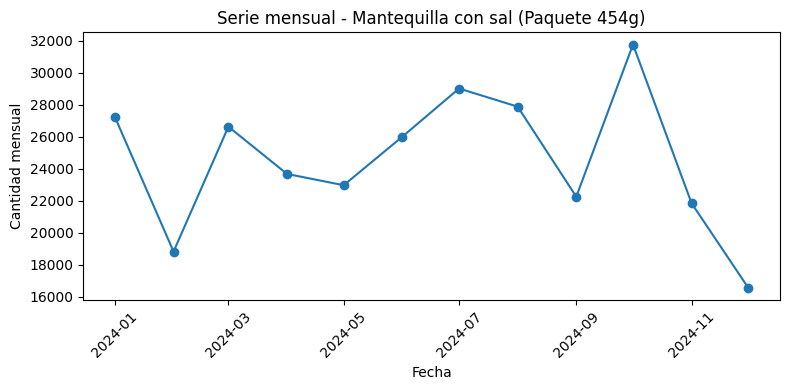

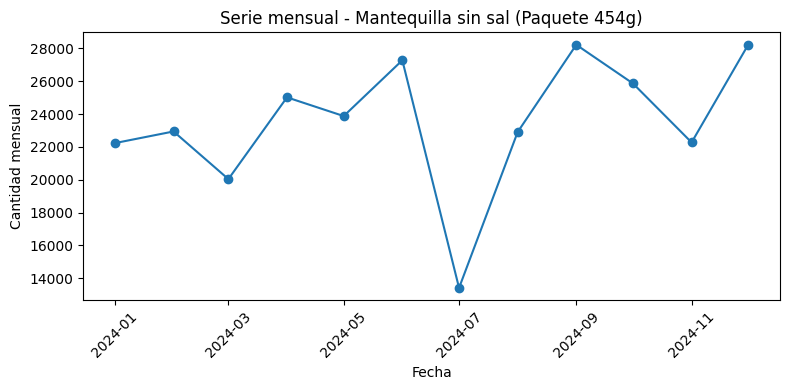

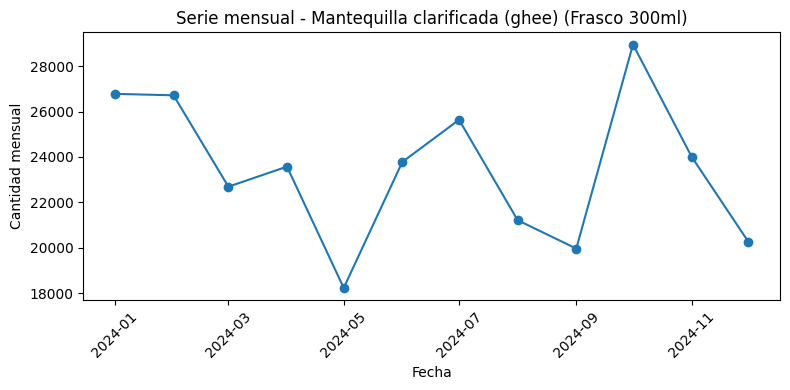

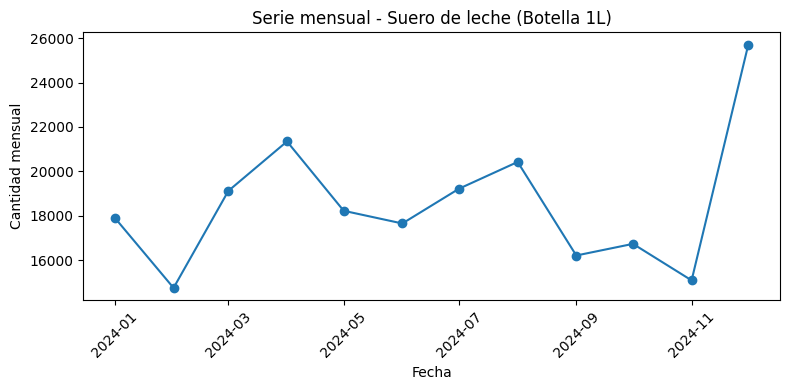

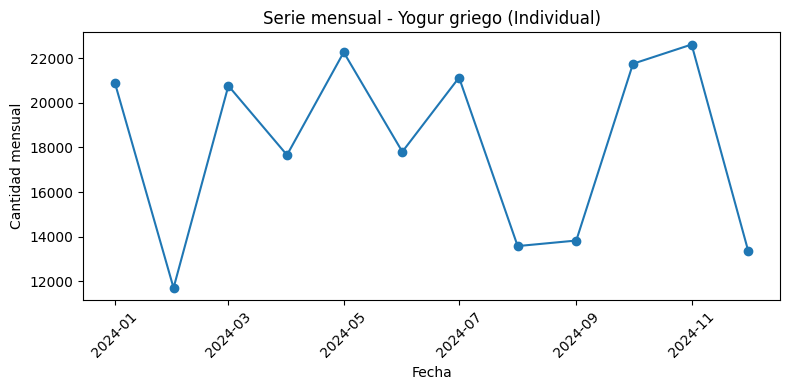

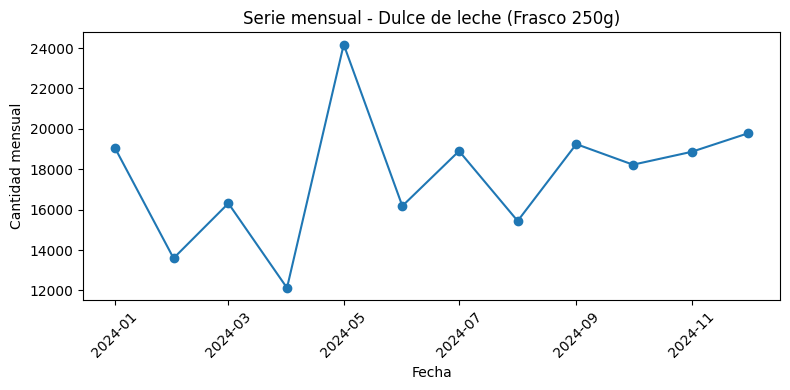

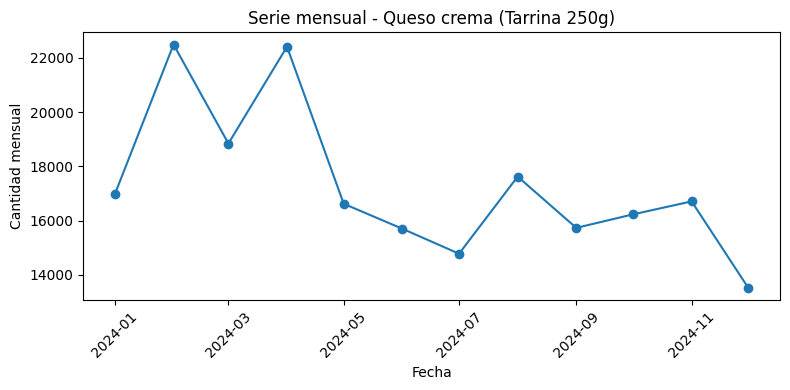

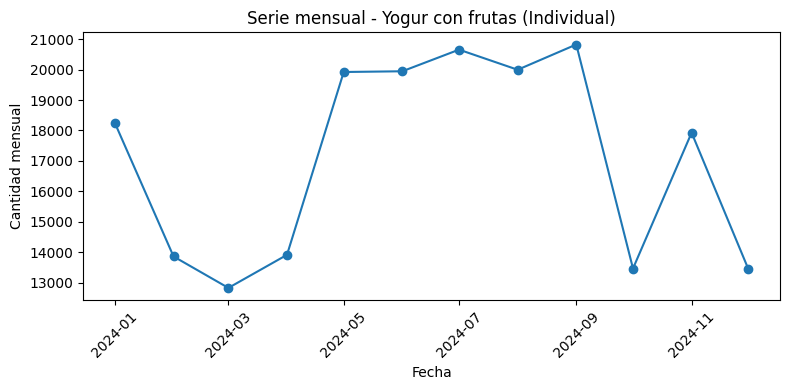

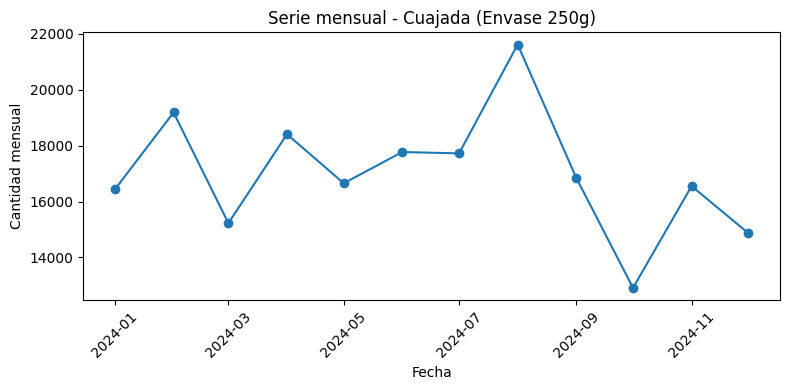

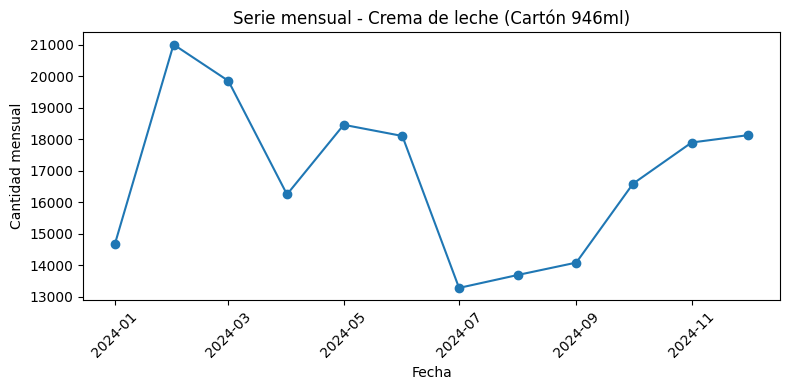

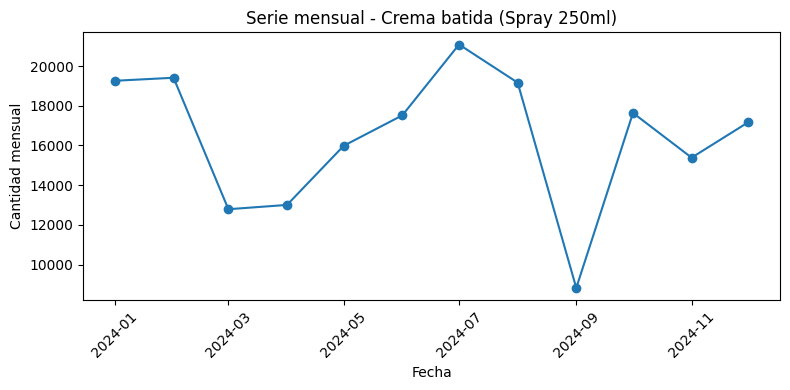

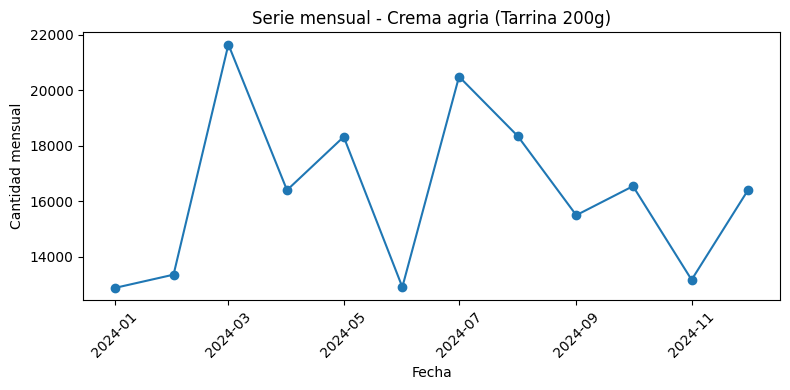

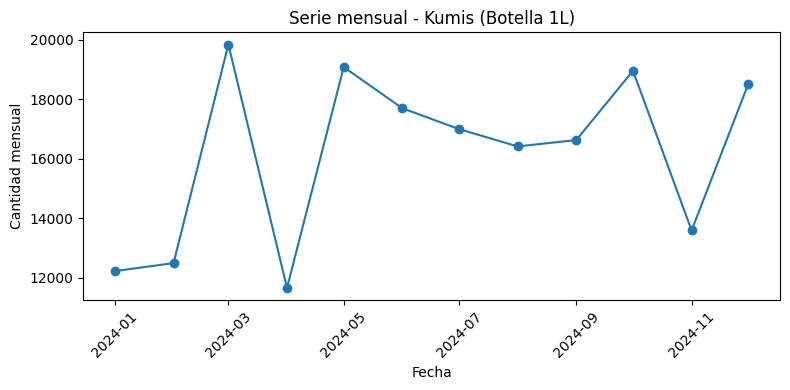

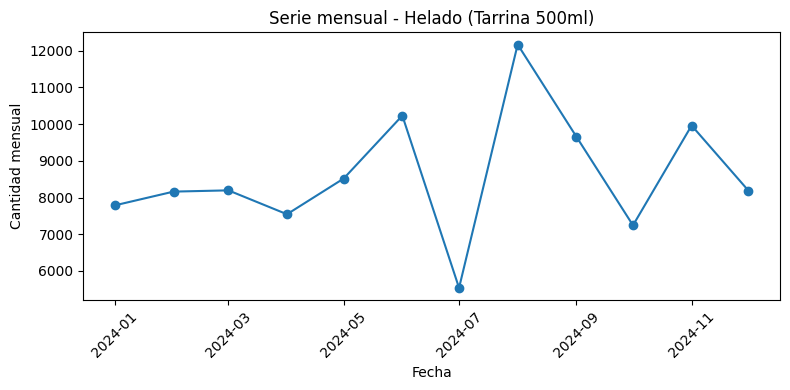

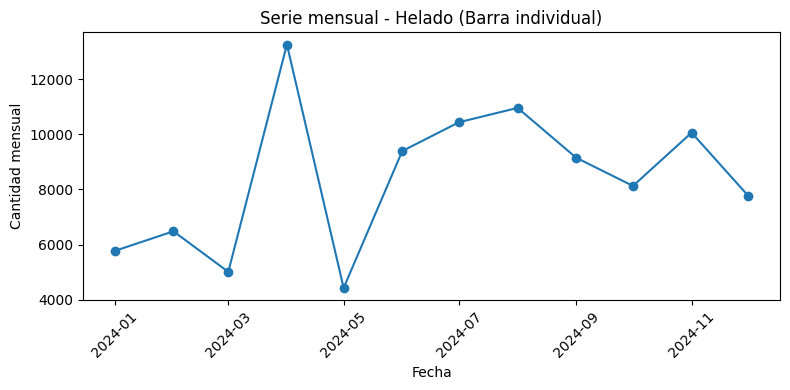

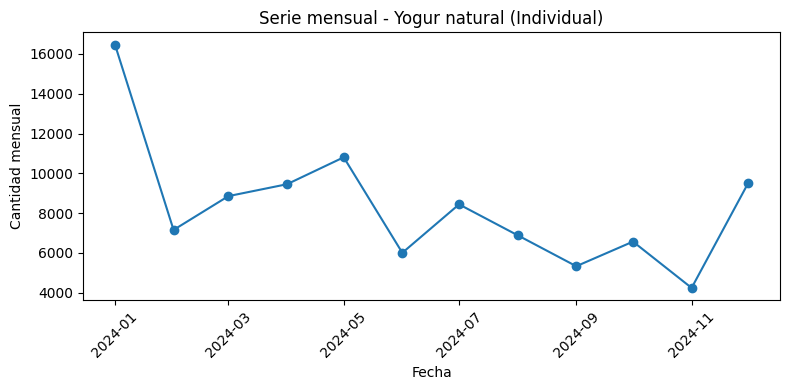

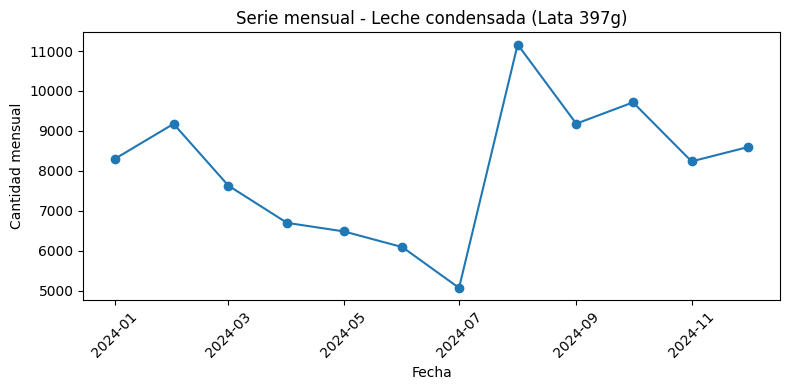

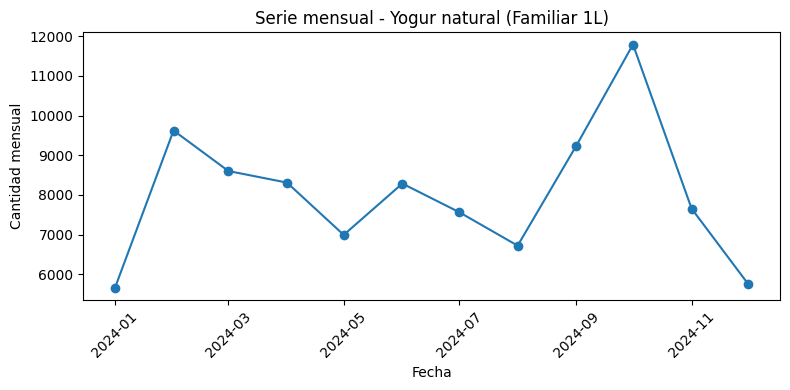

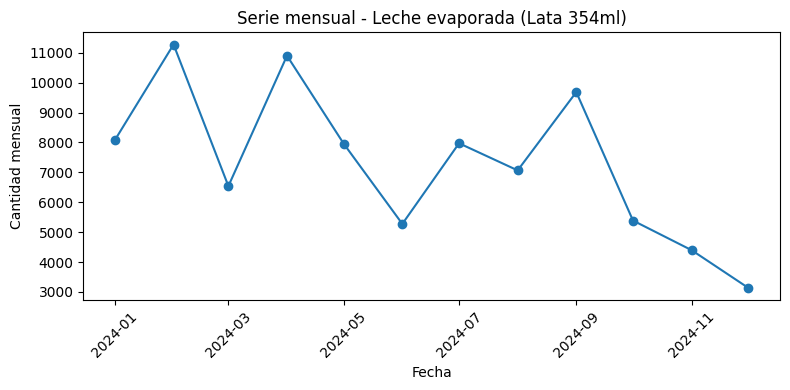

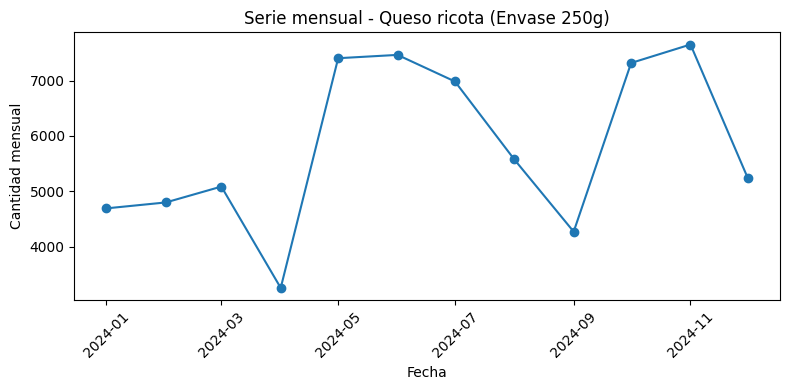

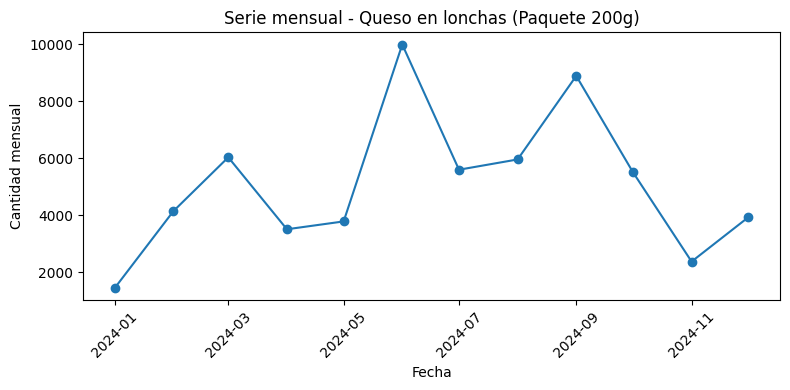

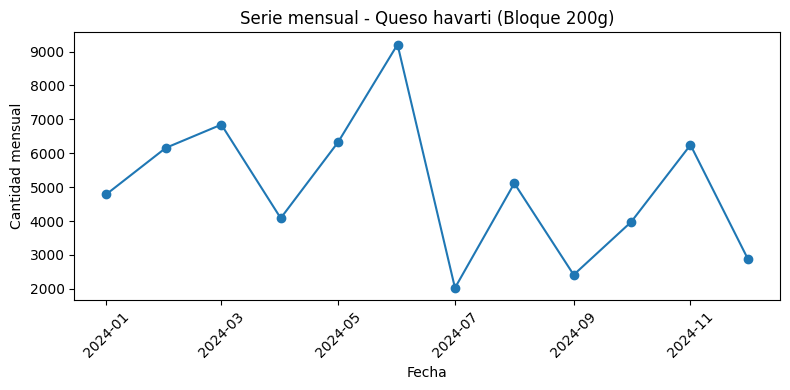

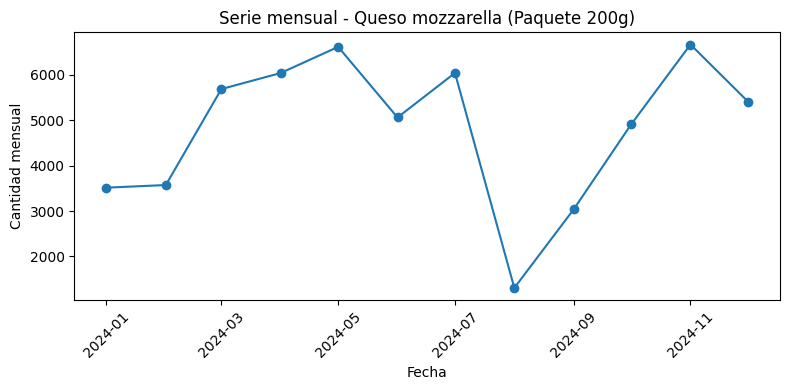

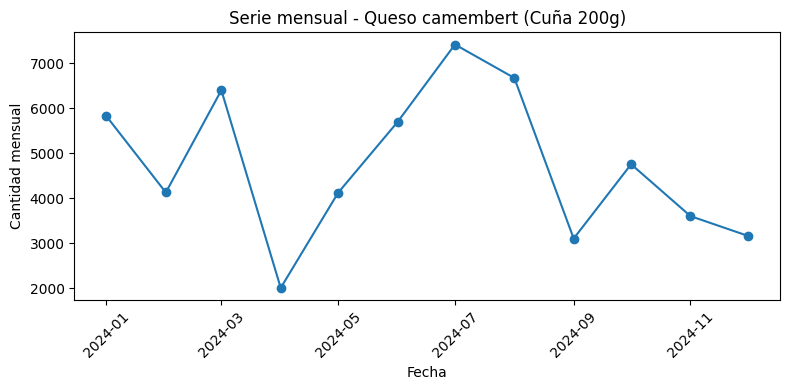

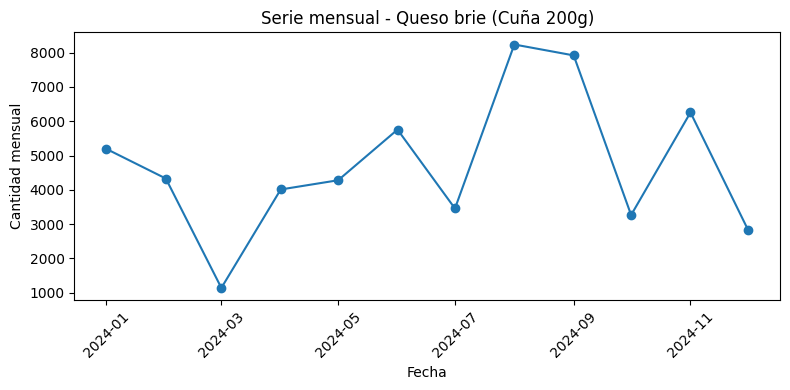

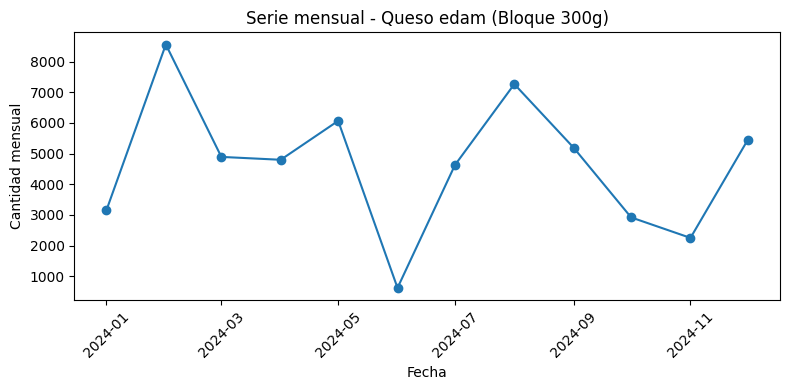

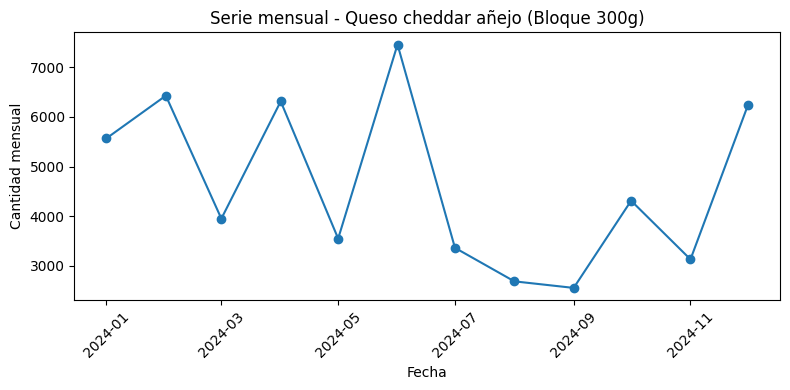

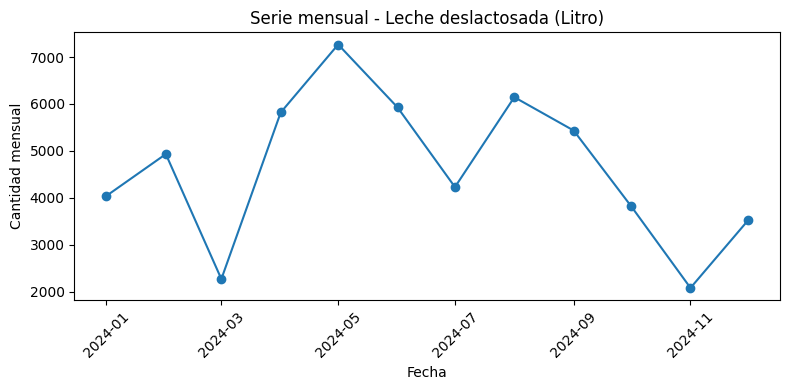

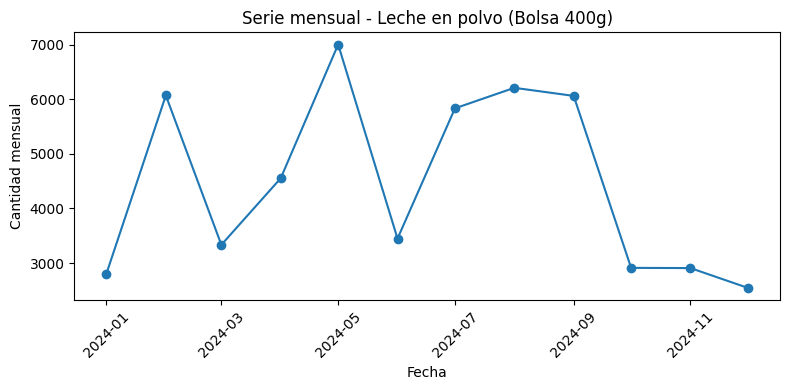

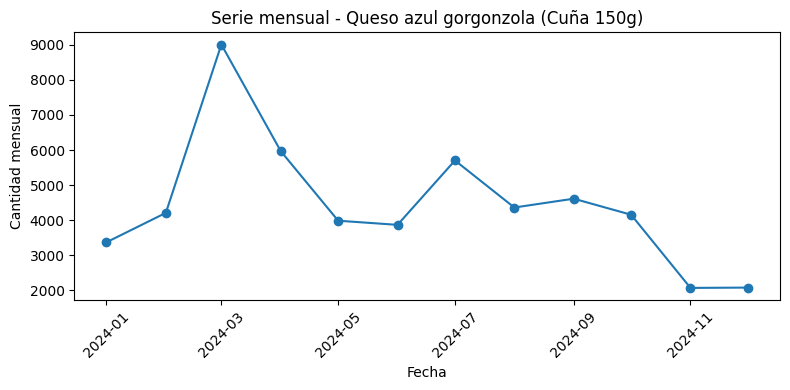

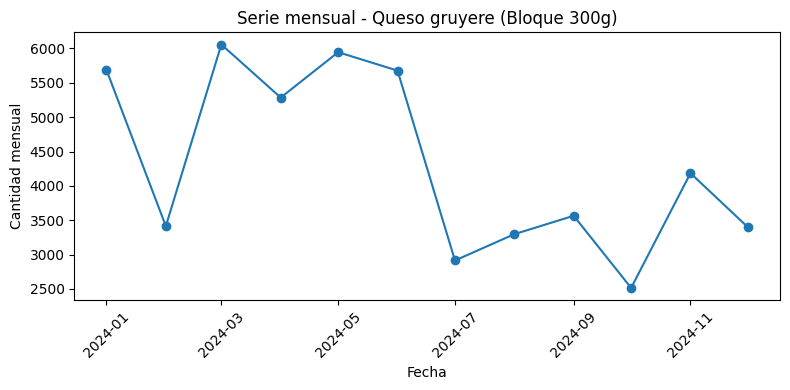

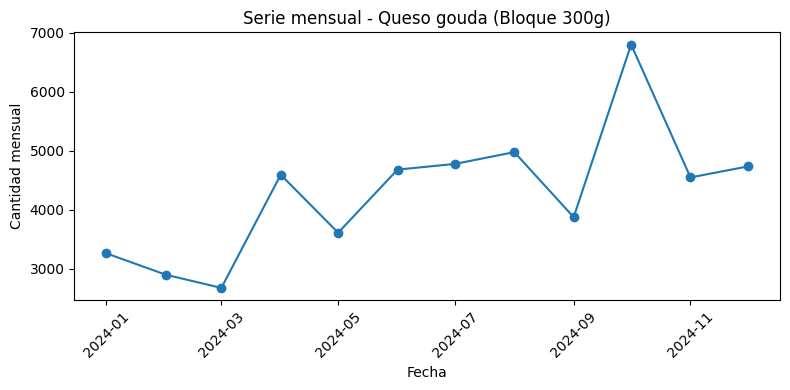

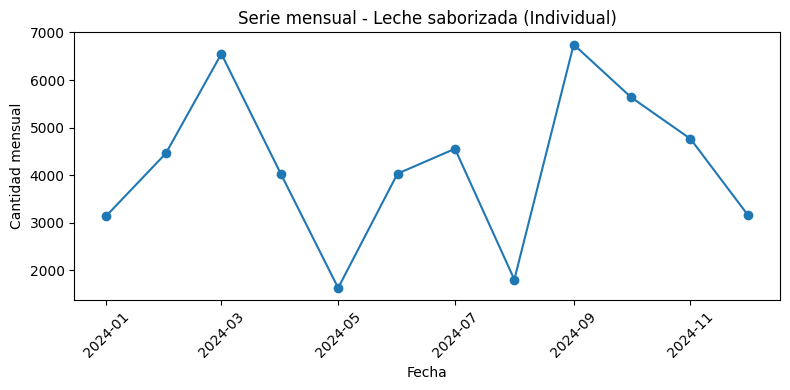

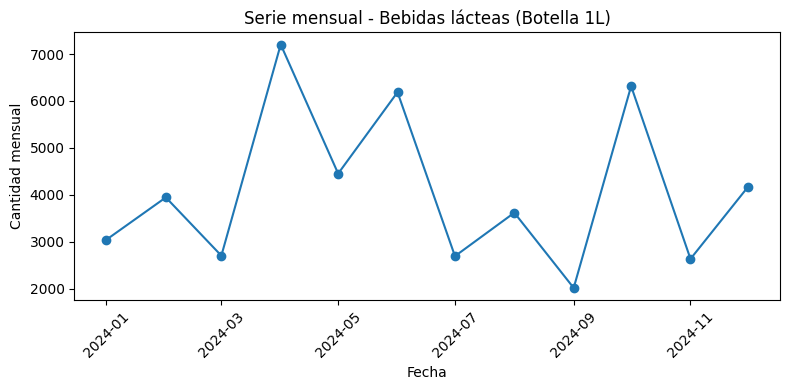

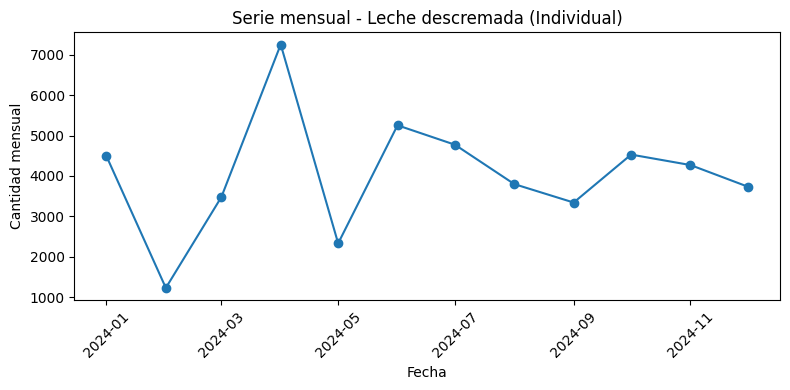

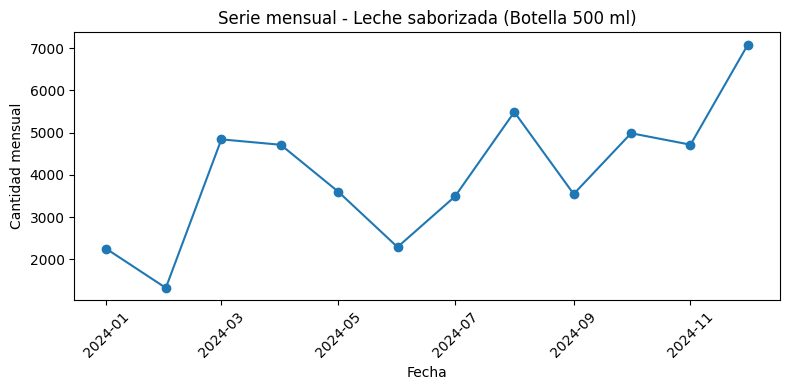

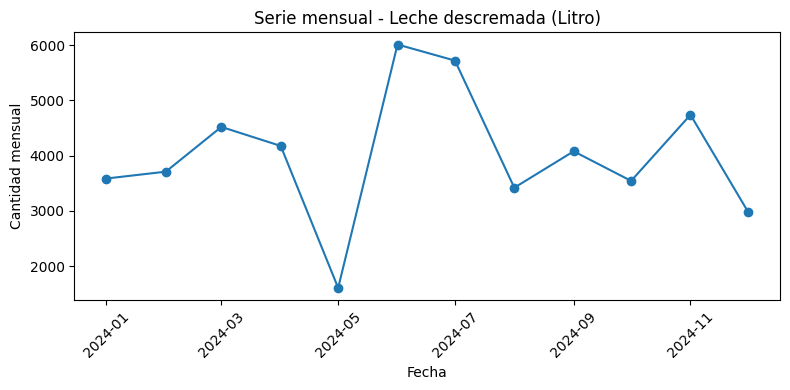

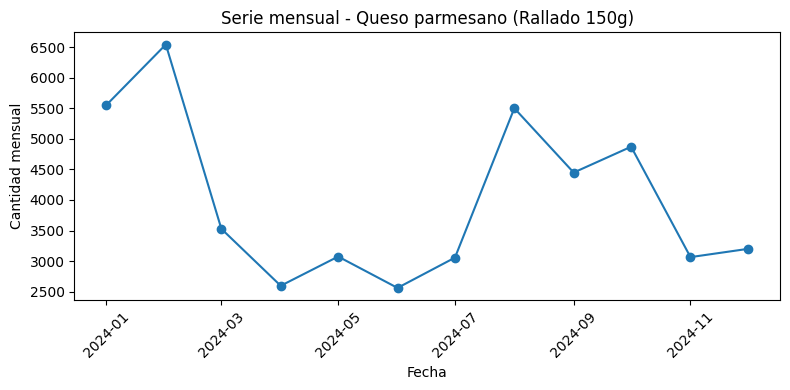

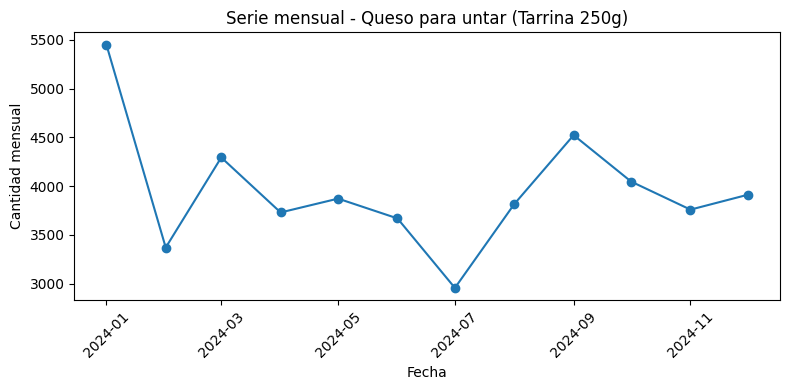

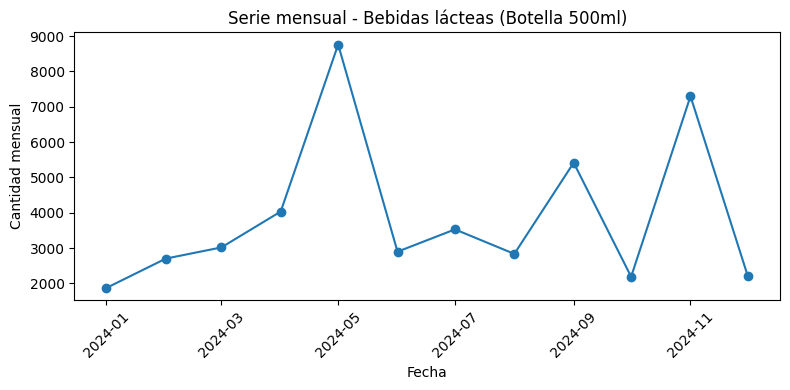

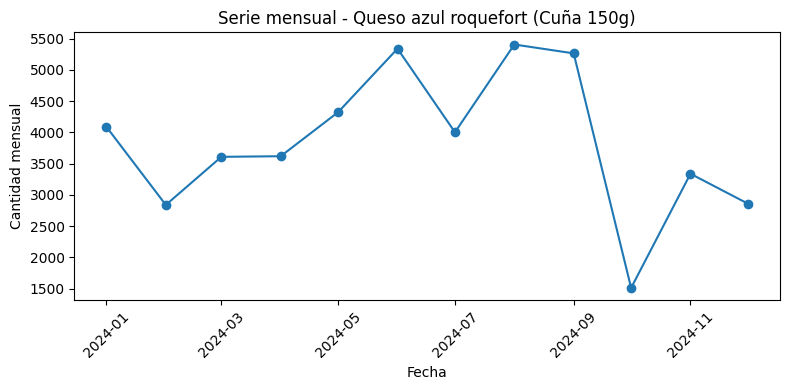

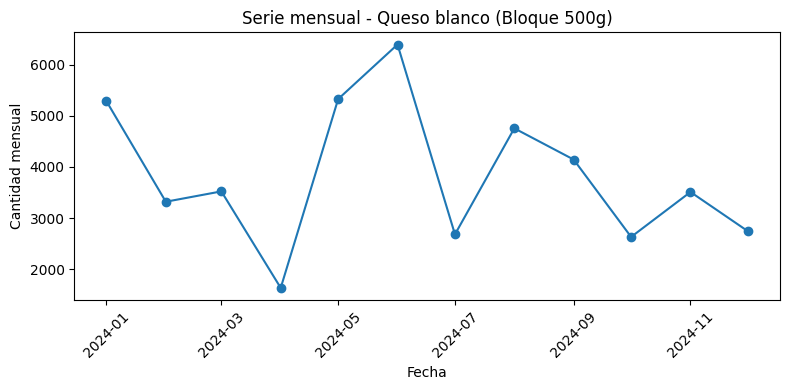

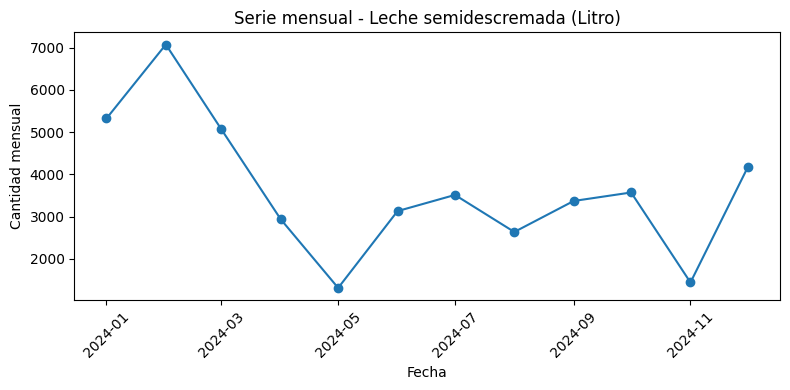

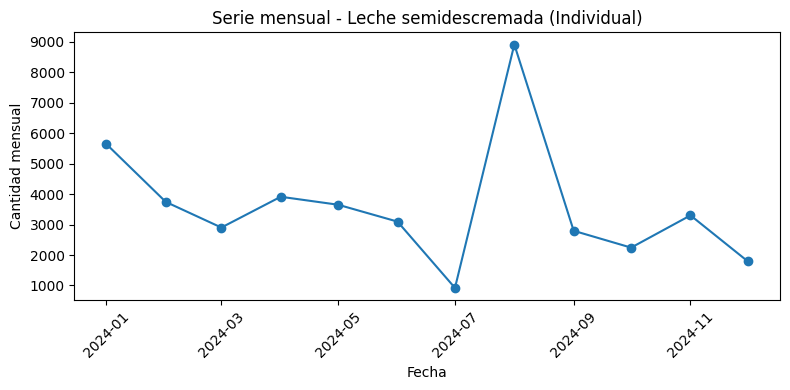

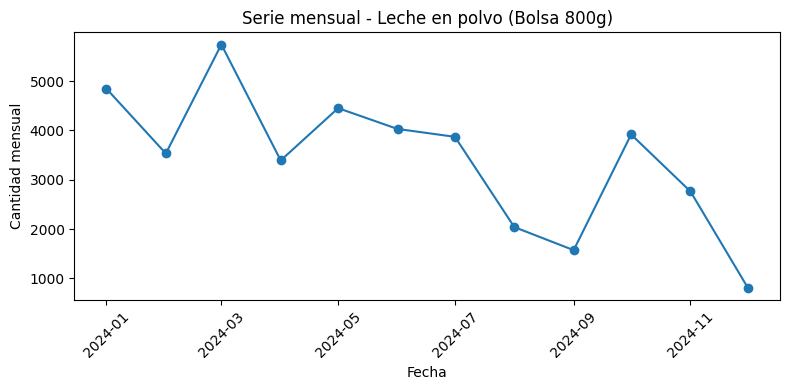

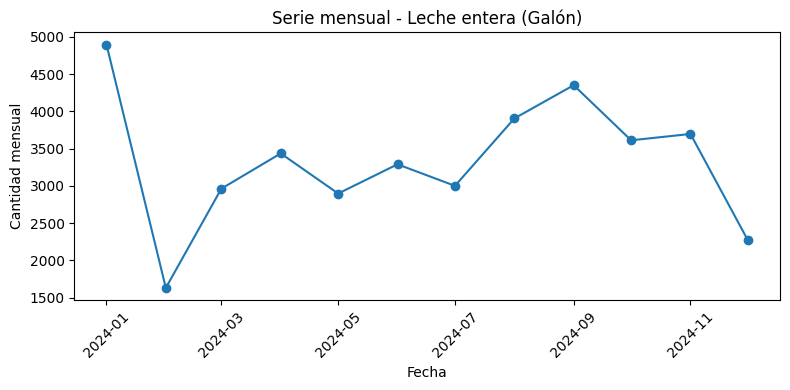

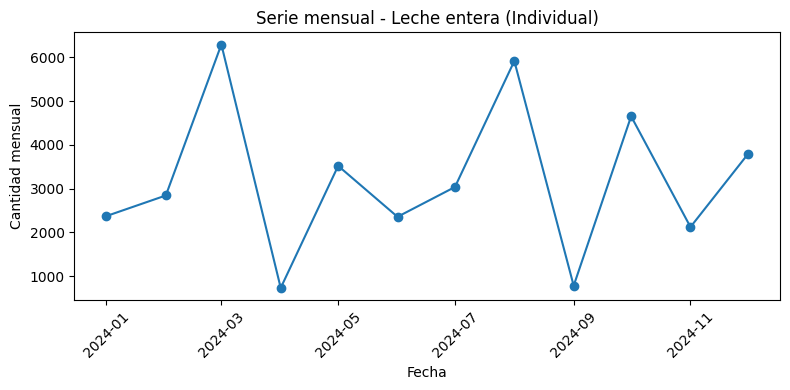

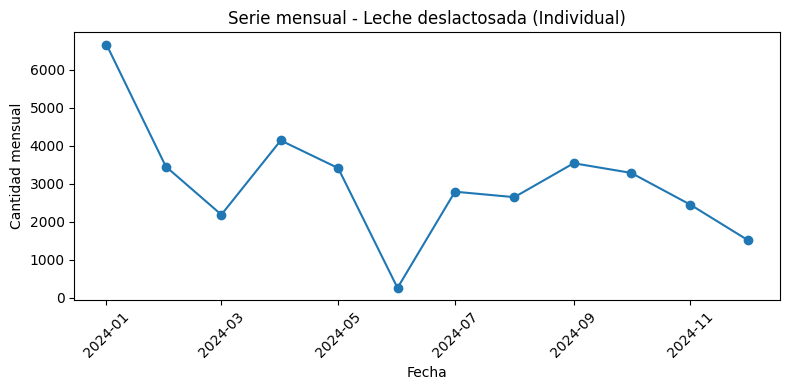

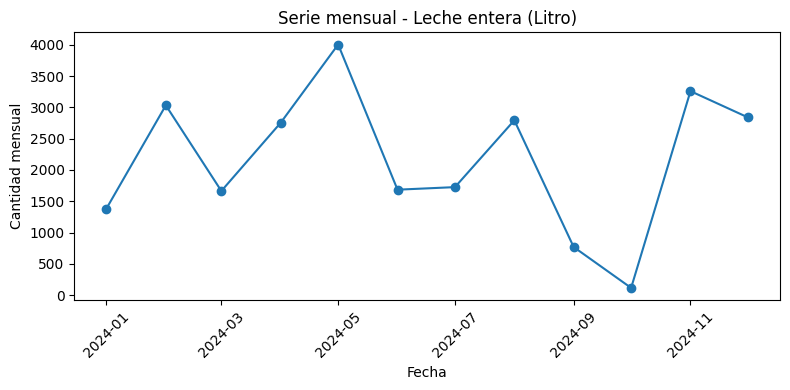

In [37]:
ruta_figures = os.path.join(os.path.dirname(os.getcwd()), 'results', 'figures', 'series_temporales')
os.makedirs(ruta_figures, exist_ok=True)

N = df_mensual.groupby(["Producto", "Presentación"]).ngroups
top_pp = (
    df_mensual.groupby(["Producto", "Presentación"])["Cantidad_mensual"]
    .sum()
    .sort_values(ascending=False)
    .head(N)
    .reset_index()[["Producto", "Presentación"]]
    .values.tolist()
)

for prod, pres in top_pp:
    sub = df_mensual[(df_mensual["Producto"] == prod) & (df_mensual["Presentación"] == pres)]
    sub = sub.sort_values("Fecha_mes")

    plt.figure(figsize=(8, 4))
    plt.plot(sub["Fecha_mes"], sub["Cantidad_mensual"], marker="o")
    plt.title(f"Serie mensual - {prod} ({pres})")
    plt.xlabel("Fecha")
    plt.ylabel("Cantidad mensual")
    plt.xticks(rotation=45)
    plt.tight_layout()

    nombre_archivo = f"{prod}_{pres}.png".replace(" ", "_").replace("/", "-")
    ruta_imagen = os.path.join(ruta_figures, nombre_archivo)
    plt.savefig(ruta_imagen, dpi=150, bbox_inches="tight")
    plt.show()

En primer lugar, mantequilla es la categoría con mayor volumen absoluto durante todo el año y presenta una estacionalidad marcada, con un pico muy pronunciado en octubre y valores relativamente altos también en junio. Además, desciende hacia noviembre–diciembre, lo que sugiere que su máximo no coincide exactamente con fin de año sino ligeramente antes.

Las cremas muestran un comportamiento relativamente estable, aunque con un mínimo claro en septiembre y recuperación posterior. Tienen una variabilidad moderada, sin cambios extremos.

La leche es la categoría más estable y de menor variabilidad relativa: oscila suavemente alrededor de un nivel bastante constante, con ligera subida en abril y agosto y descenso progresivo hacia final de año. Es la serie más “predecible”.

Los quesos presentan un pico claro en junio y un segundo repunte en agosto, seguido de descenso gradual hasta diciembre. Muestran estacionalidad intermedia, más marcada que leche pero menos que mantequilla.

El yogur tiene oscilaciones visibles: destaca mayo como máximo claro y febrero como mínimo pronunciado. Parece responder a patrones de consumo más variables, posiblemente asociados a hábitos estacionales o promociones.

La categoría otros presenta un aumento progresivo desde febrero hasta agosto (máximo anual) y luego una caída en octubre, con recuperación en diciembre

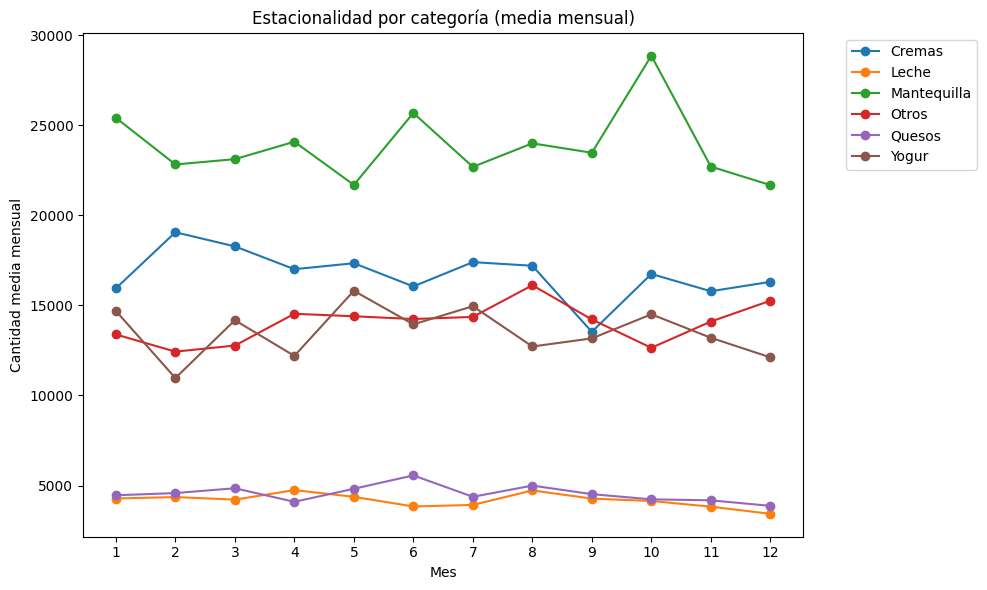

In [ ]:
estacionalidad_cat = (
    df_mensual.groupby(["Categoría", "Mes"])["Cantidad_mensual"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
for categoria, sub in estacionalidad_cat.groupby("Categoría"):
    plt.plot(sub["Mes"], sub["Cantidad_mensual"], marker="o", label=categoria)

plt.xticks(range(1, 13))
plt.xlabel("Mes")
plt.ylabel("Cantidad media mensual")
plt.title("Estacionalidad por categoría (media mensual)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 6. Correlación de productos

- Fuerte bloque entre leches: leche entera, semidescremada, descremada, evaporada y en polvo muestran correlaciones elevadas entre sí, indicando que comparten prácticamente el mismo patrón estacional y dinámica de demanda.

- Alta correlación entre mantequillas: mantequilla con sal, sin sal y ghee presentan co-movimiento claro, formando un subgrupo muy consistente.

- Bloque de yogures: yogur natural, griego y con frutas presentan correlaciones positivas relevantes, lo que indica comportamiento de consumo conjunto.

- Quesos gourmet entre sí: azul (roquefort/gorgonzola), brie y camembert muestran correlaciones elevadas, sugiriendo un patrón común vinculado a celebraciones o consumo ocasional.

En conjunto, las altas correlaciones revelan clusters naturales bien definidos por categoría y tipo de producto, lo que confirma una fuerte co-movilidad dentro de cada familia.

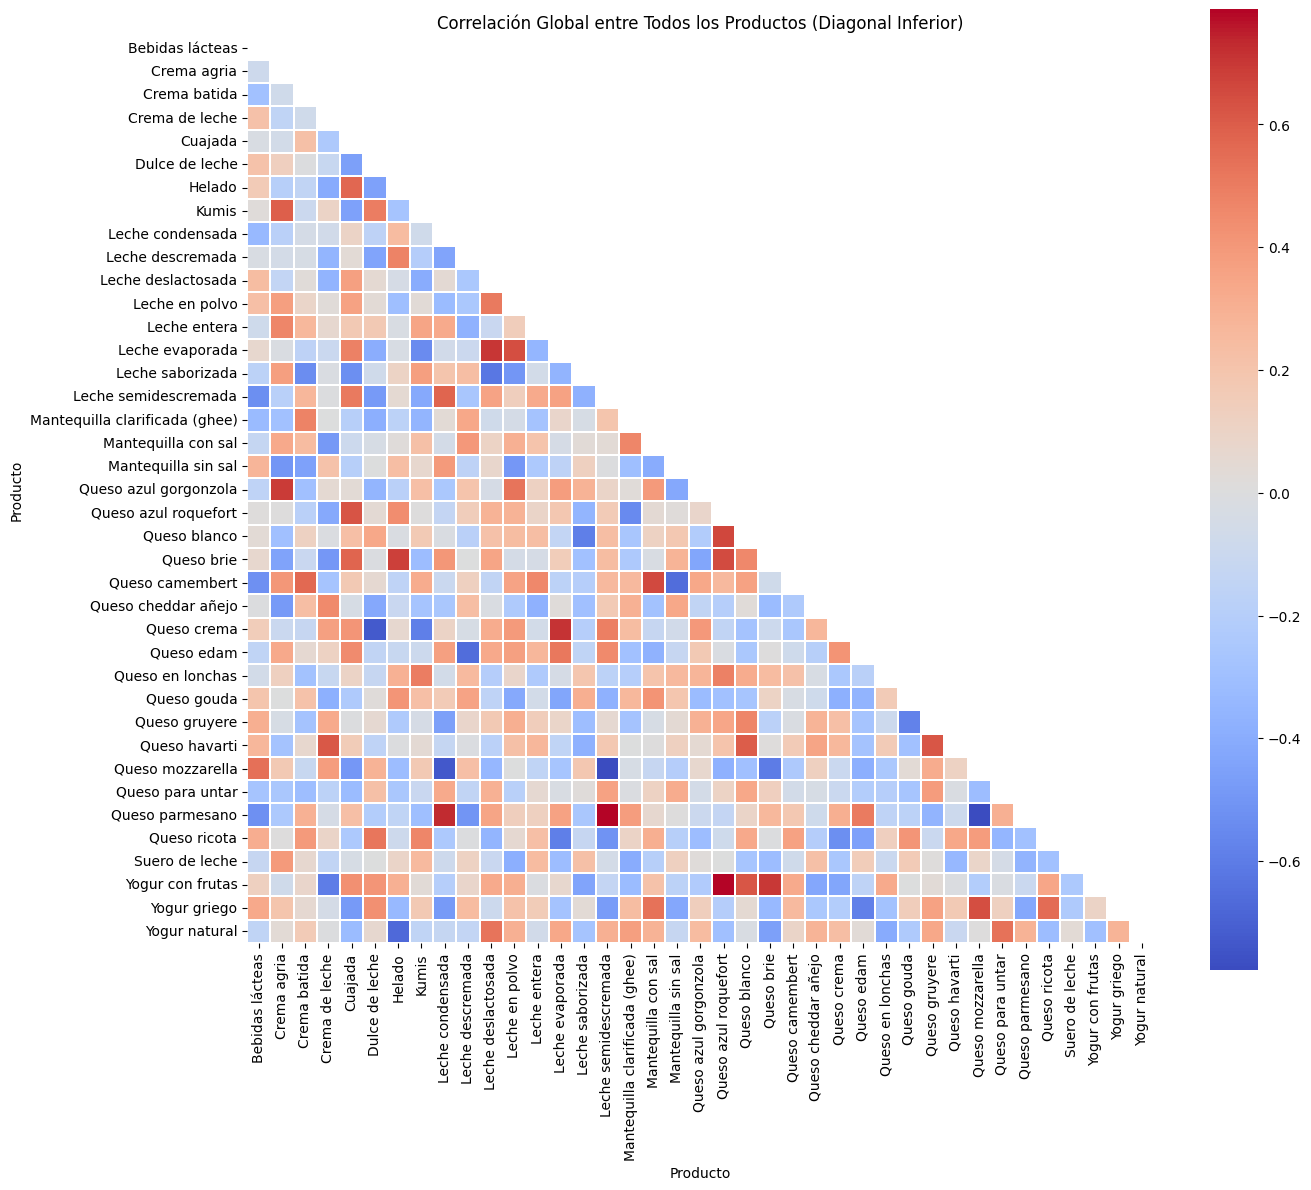

In [42]:
pivot_all = df_mensual.pivot_table(
    values="Cantidad_mensual",
    index="Fecha_mes",
    columns="Producto",
    fill_value=0
)

# Matriz de correlación
corr_all = pivot_all.corr()

# Crear máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr_all, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_all,
    mask=mask,               
    cmap="coolwarm",
    annot=False,
    linewidths=0.3,
    square=True
)
plt.title("Correlación Global entre Todos los Productos (Diagonal Inferior)")
plt.tight_layout()
plt.show()


### 7. Detección de outliers

Para cada combinación Producto+Presentación, identificamos los meses con 
ventas anormalmente altas o bajas usando el método **IQR (rango intercuartílico)**.
Un mes se considera outlier si su cantidad vendida cae fuera del intervalo 
[Q1 - 1.5·IQR, Q3 + 1.5·IQR], y se clasifica como "Alto" o "Bajo" según 
si supera el límite superior o inferior respectivamente.

> ⚠️ Con solo 12 meses de histórico por serie, este método tiene una fiabilidad 
> limitada al calcular el IQR con pocas observaciones. Los resultados deben 
> interpretarse con cautela.

In [43]:
outliers = []

for (prod, pres), sub in df_mensual.groupby(["Producto", "Presentación"]):
    q1 = sub["Cantidad_mensual"].quantile(0.25)
    q3 = sub["Cantidad_mensual"].quantile(0.75)
    IQR = q3 - q1
    
    limite_inf = q1 - 1.5 * IQR
    limite_sup = q3 + 1.5 * IQR
    
    sub_out = sub[(sub["Cantidad_mensual"] < limite_inf) | (sub["Cantidad_mensual"] > limite_sup)]
    for _, row in sub_out.iterrows():
        outliers.append({
            "Producto": prod,
            "Presentación": pres,
            "Fecha": row["Fecha_mes"],
            "Cantidad": row["Cantidad_mensual"],
            "Tipo": "Alto" if row["Cantidad_mensual"] > limite_sup else "Bajo"
        })

df_outliers = pd.DataFrame(outliers)
display(df_outliers.head(20))

,Producto,Presentación,Fecha,Cantidad,Tipo
0,Bebidas lácteas,Botella 500ml,2024-05-01,8763,Alto
1,Bebidas lácteas,Botella 500ml,2024-11-01,7300,Alto
2,Cuajada,Envase 250g,2024-08-01,21621,Alto
3,Cuajada,Envase 250g,2024-10-01,12908,Bajo
4,Dulce de leche,Frasco 250g,2024-05-01,24174,Alto
5,Leche descremada,Individual,2024-02-01,1229,Bajo
6,Leche descremada,Individual,2024-04-01,7254,Alto
7,Leche descremada,Litro,2024-05-01,1608,Bajo
8,Leche deslactosada,Individual,2024-01-01,6659,Alto
9,Leche deslactosada,Individual,2024-06-01,253,Bajo


### 8. Análisis de autocorrelación (ACF y PACF)

Para decidir qué tipo de modelo de series temporales usar (ARIMA, SARIMA, etc.), 
es útil analizar si las ventas de un mes están correlacionadas con las de meses 
anteriores. Para ello calculamos dos métricas para cada producto:

- **ACF (Función de Autocorrelación):** mide la correlación entre la serie y 
sus versiones retrasadas (lags). Ayuda a identificar patrones de estacionalidad 
y a determinar el parámetro q de un modelo ARIMA.

- **PACF (Función de Autocorrelación Parcial):** mide la correlación directa 
entre la serie y cada lag, eliminando el efecto de los lags intermedios. 
Ayuda a determinar el parámetro p de un modelo ARIMA.

> ⚠️ Con solo 12 meses de histórico, el número de lags disponibles es muy 
> limitado, por lo que las conclusiones que se puedan extraer de estas gráficas 
> son orientativas.


=== Producto: Crema agria | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

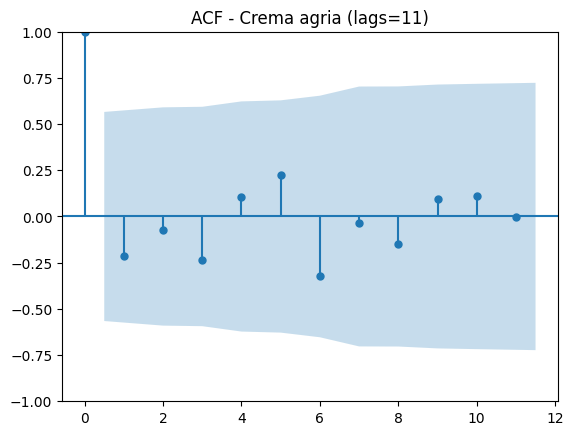

<Figure size 1000x400 with 0 Axes>

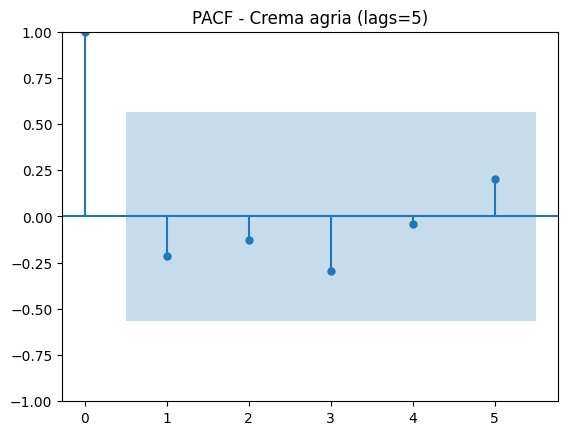


=== Producto: Crema batida | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

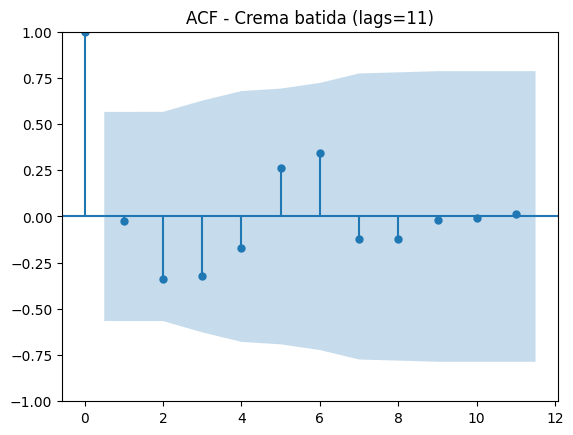

<Figure size 1000x400 with 0 Axes>

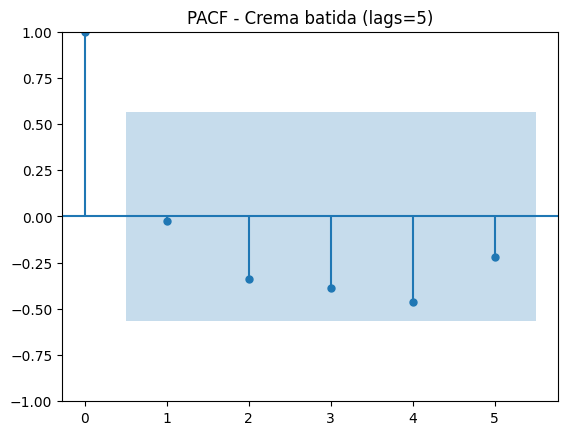


=== Producto: Crema de leche | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

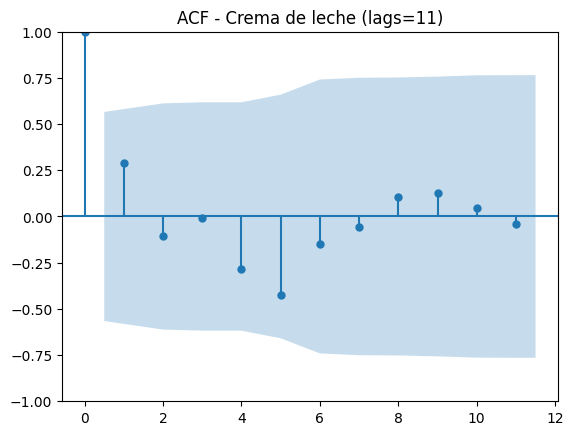

<Figure size 1000x400 with 0 Axes>

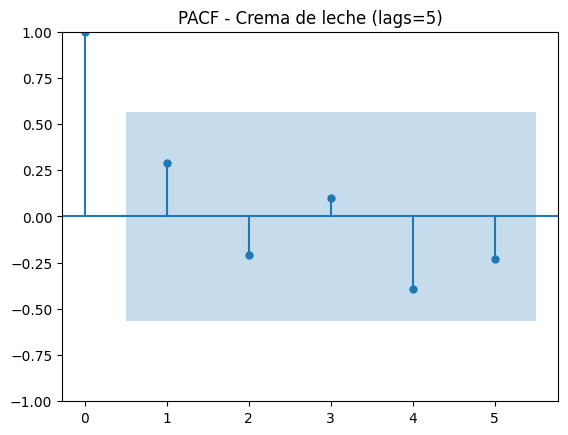


=== Producto: Queso crema | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

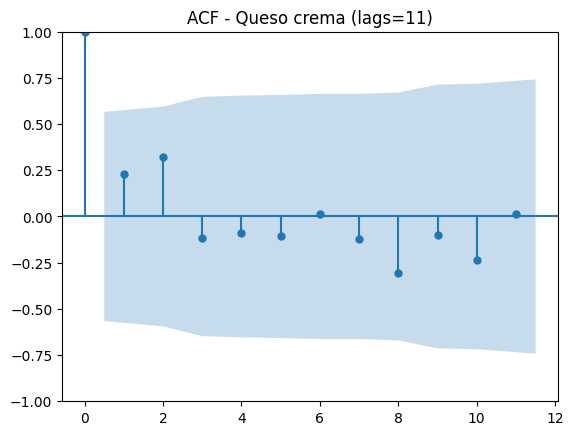

<Figure size 1000x400 with 0 Axes>

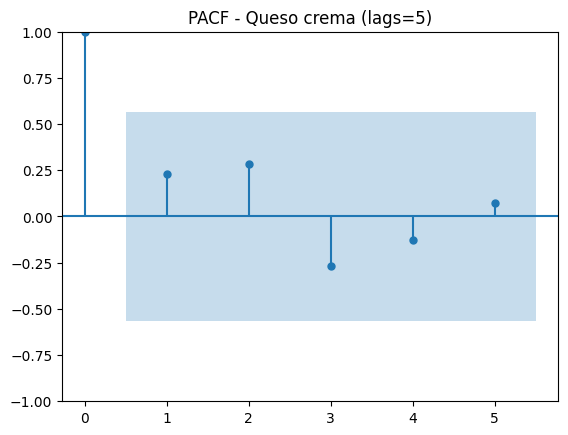


=== Producto: Bebidas lácteas | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

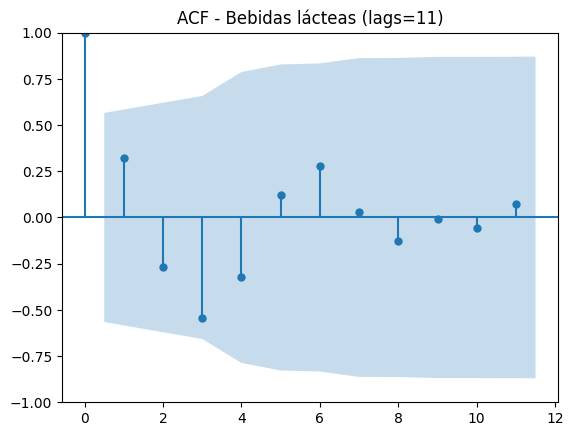

<Figure size 1000x400 with 0 Axes>

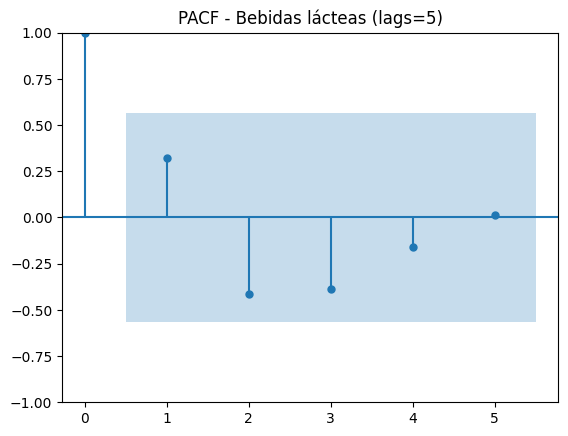


=== Producto: Leche condensada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

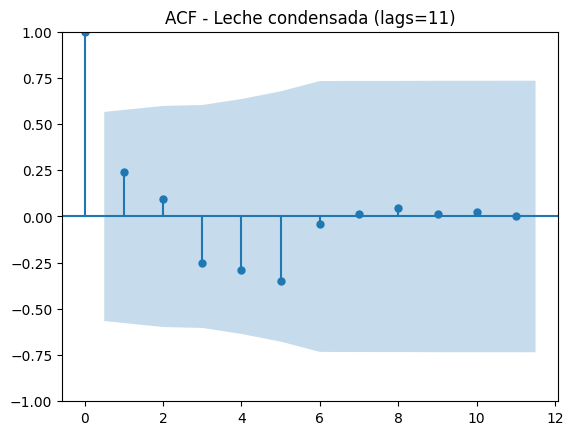

<Figure size 1000x400 with 0 Axes>

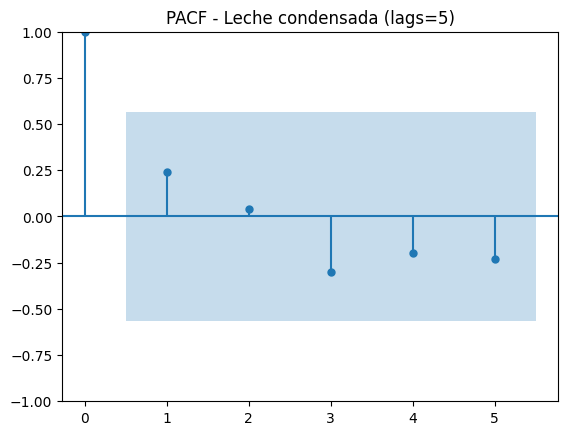


=== Producto: Leche descremada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

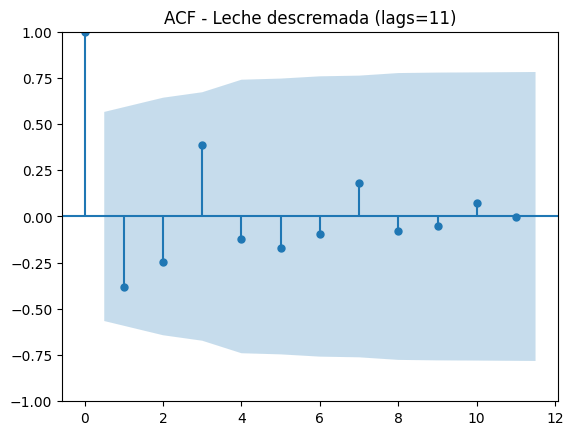

<Figure size 1000x400 with 0 Axes>

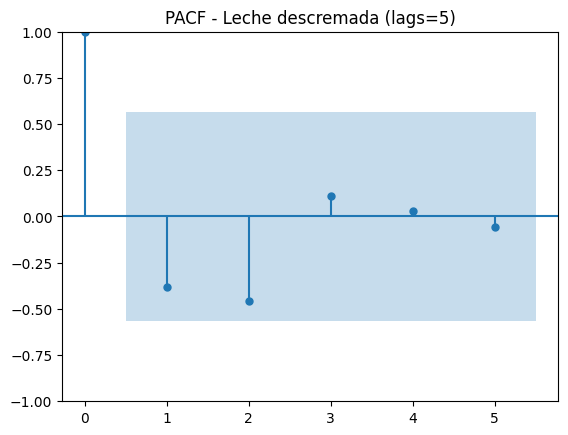


=== Producto: Leche deslactosada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

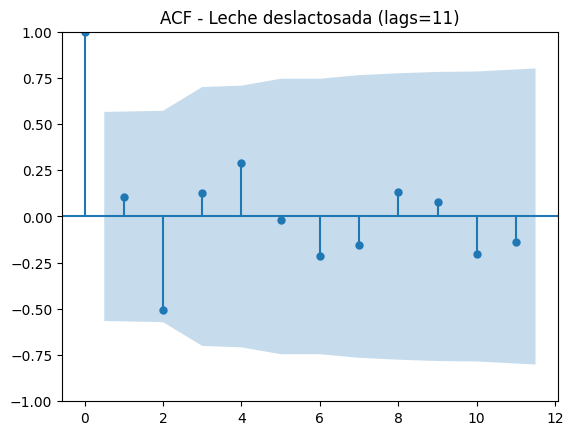

<Figure size 1000x400 with 0 Axes>

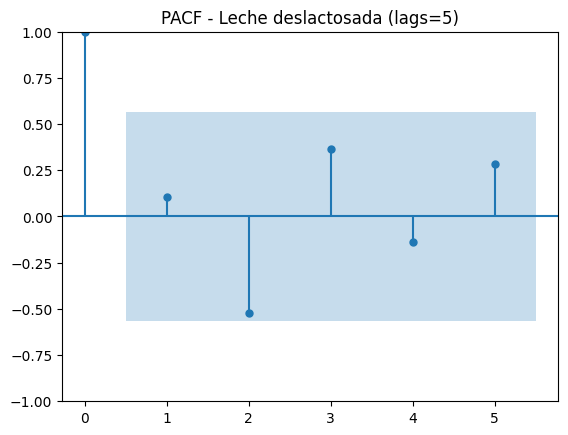


=== Producto: Leche en polvo | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

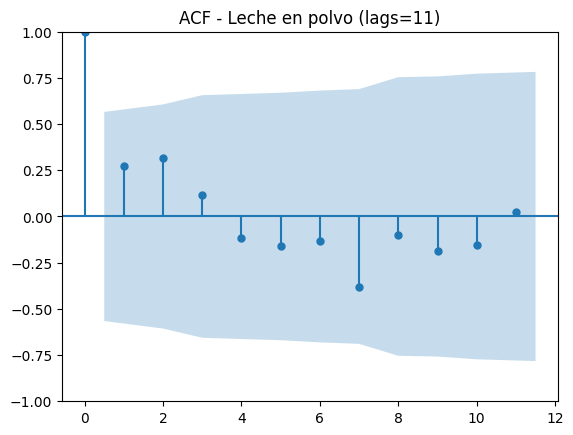

<Figure size 1000x400 with 0 Axes>

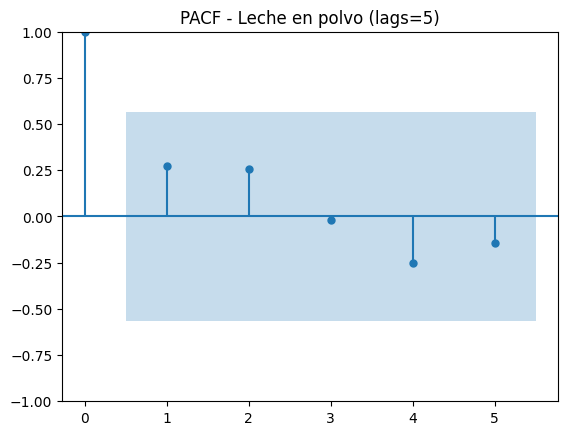


=== Producto: Leche entera | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

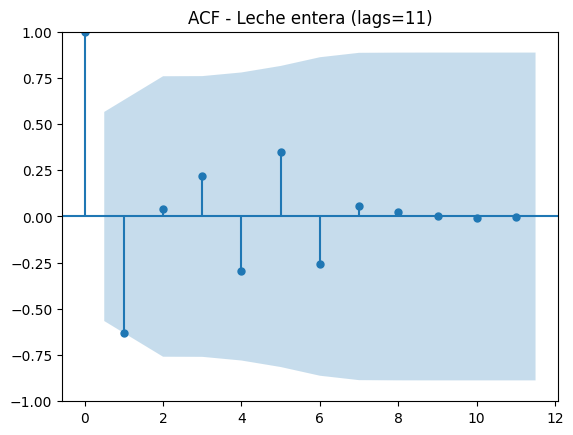

<Figure size 1000x400 with 0 Axes>

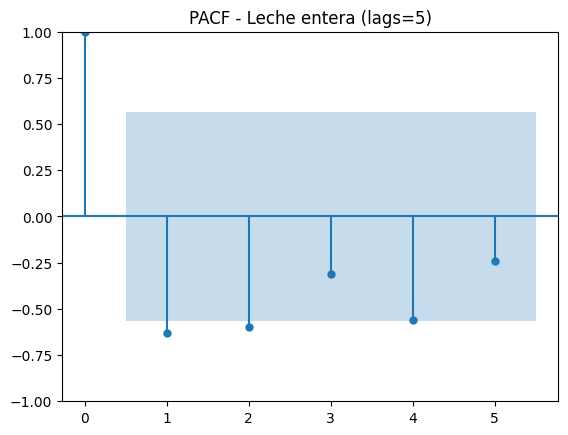


=== Producto: Leche evaporada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

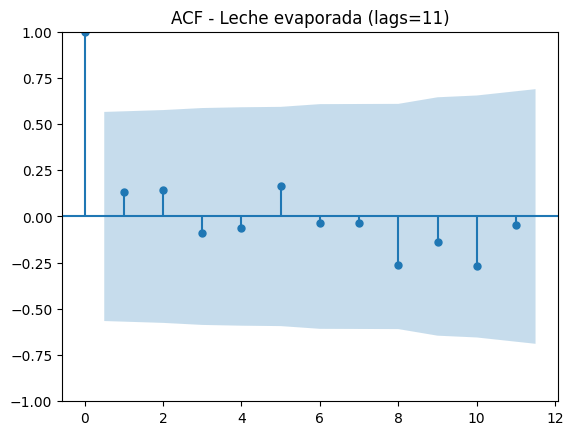

<Figure size 1000x400 with 0 Axes>

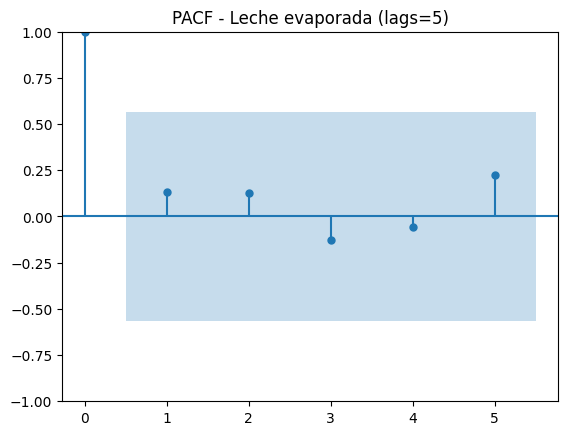


=== Producto: Leche saborizada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

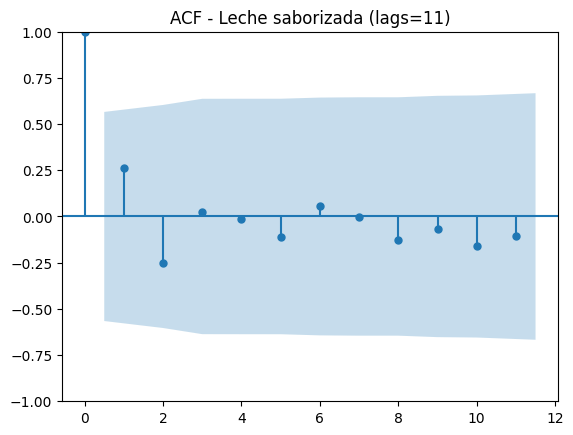

<Figure size 1000x400 with 0 Axes>

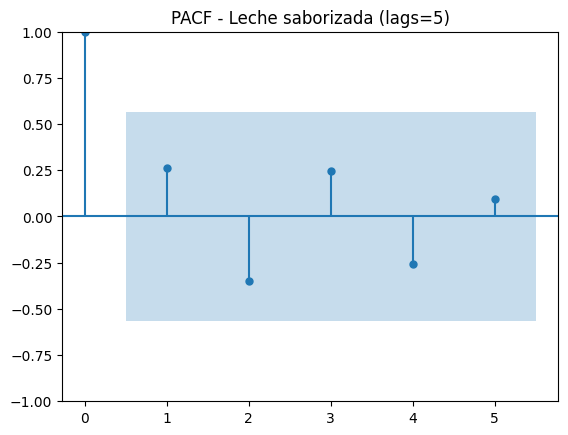


=== Producto: Leche semidescremada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

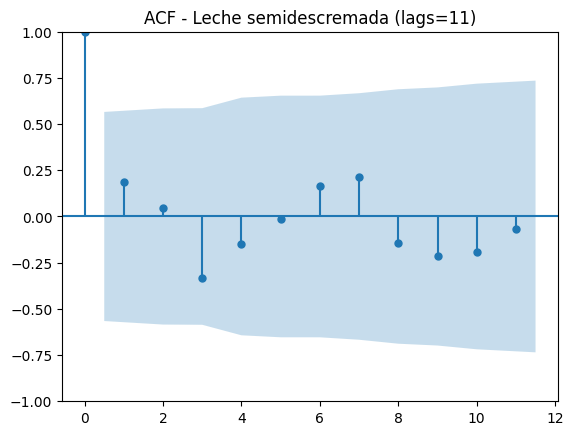

<Figure size 1000x400 with 0 Axes>

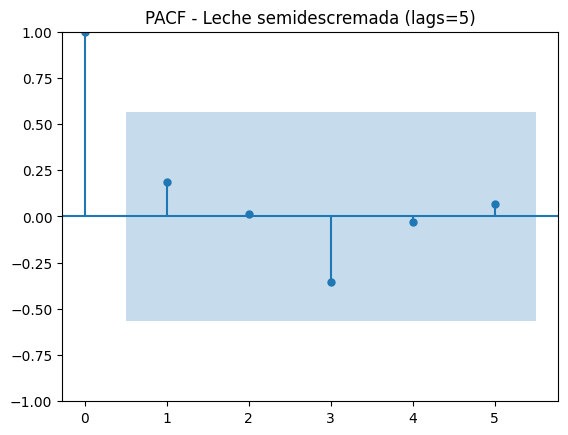


=== Producto: Mantequilla clarificada (ghee) | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

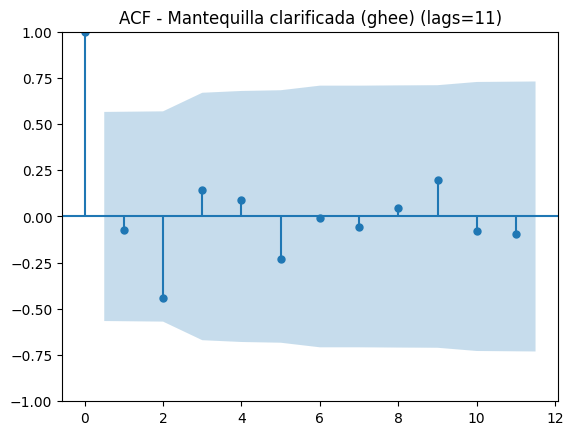

<Figure size 1000x400 with 0 Axes>

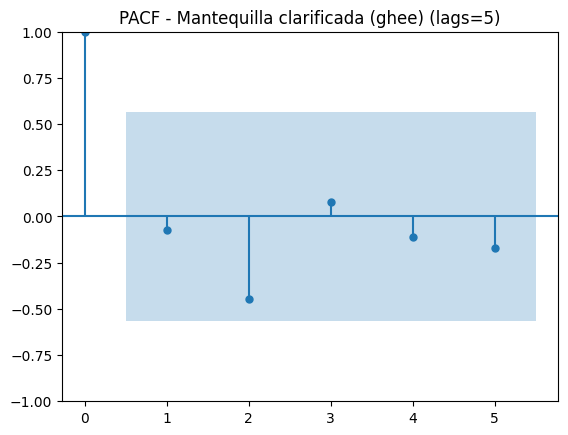


=== Producto: Mantequilla con sal | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

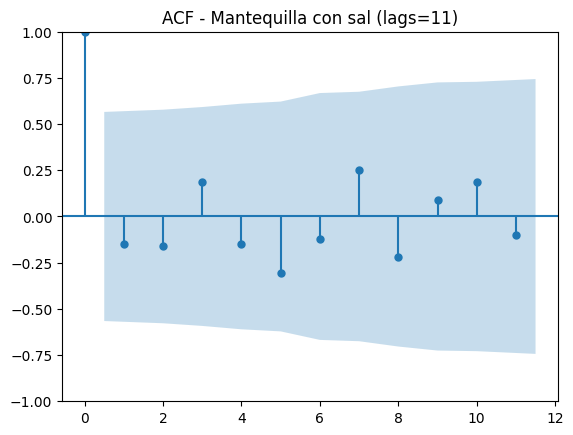

<Figure size 1000x400 with 0 Axes>

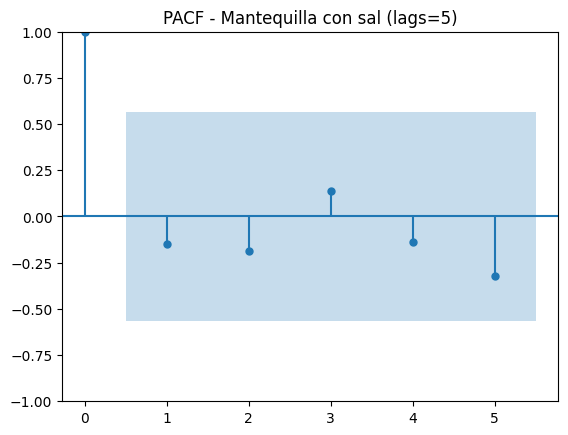


=== Producto: Mantequilla sin sal | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

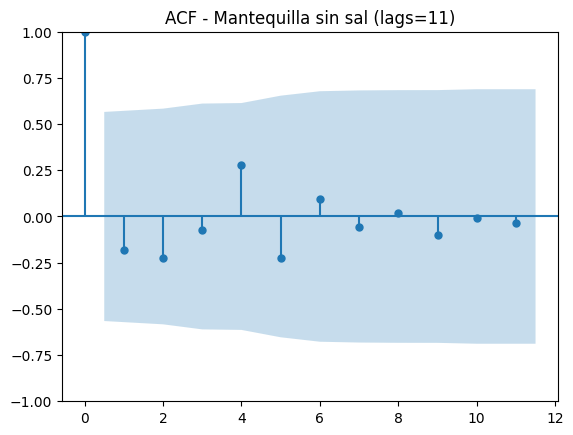

<Figure size 1000x400 with 0 Axes>

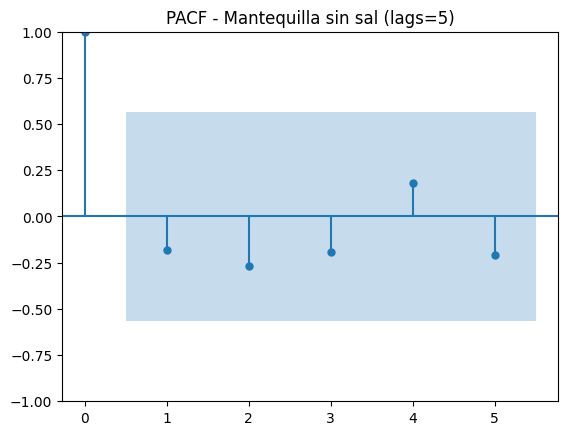


=== Producto: Cuajada | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

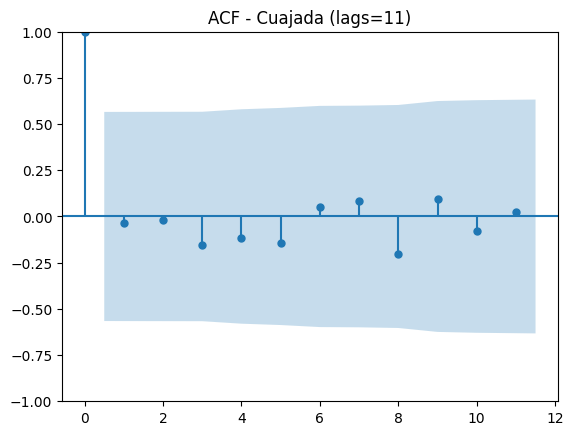

<Figure size 1000x400 with 0 Axes>

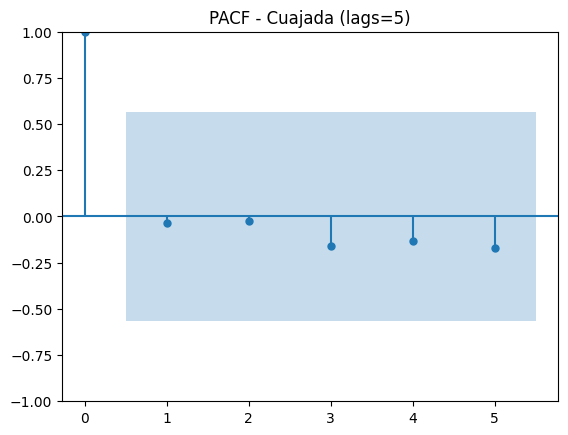


=== Producto: Dulce de leche | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

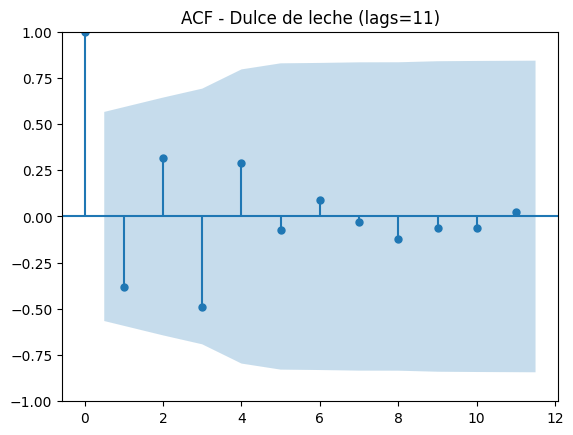

<Figure size 1000x400 with 0 Axes>

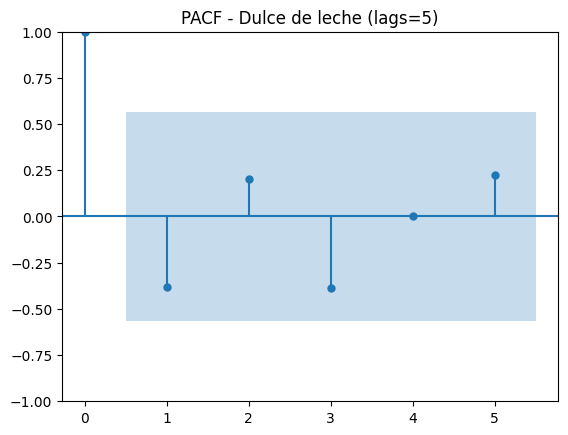


=== Producto: Helado | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

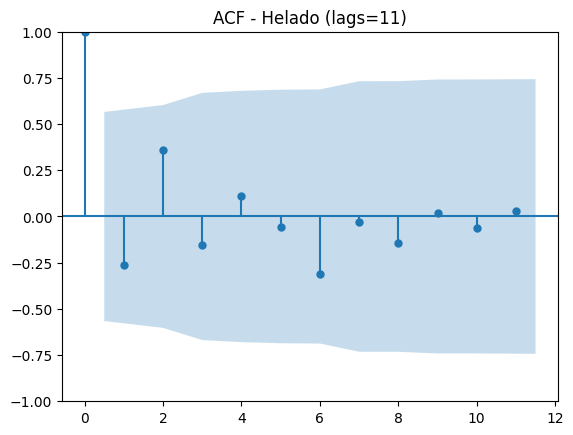

<Figure size 1000x400 with 0 Axes>

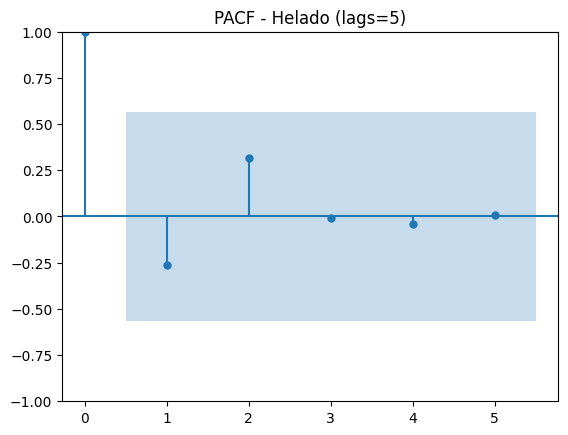


=== Producto: Suero de leche | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

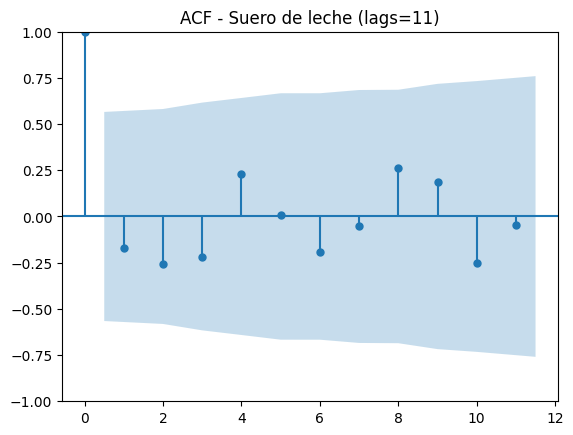

<Figure size 1000x400 with 0 Axes>

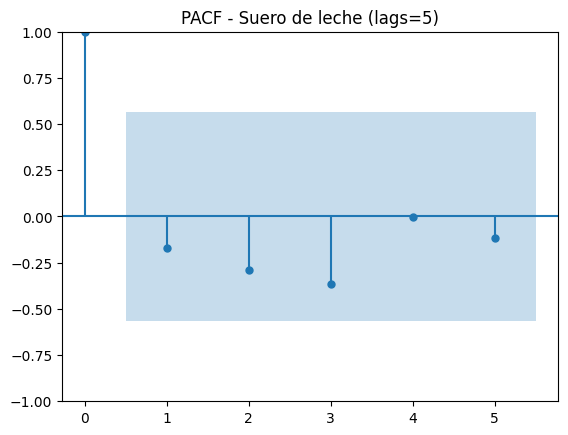


=== Producto: Queso azul gorgonzola | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

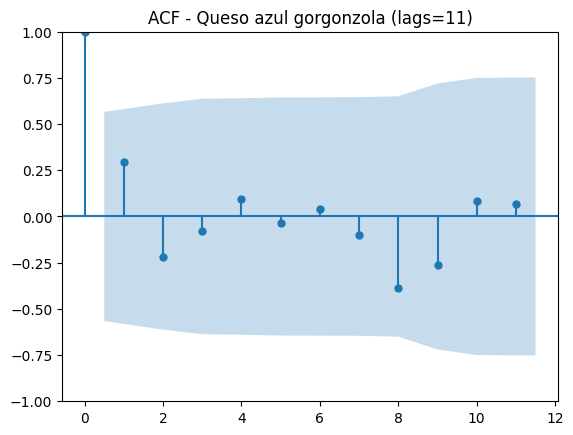

<Figure size 1000x400 with 0 Axes>

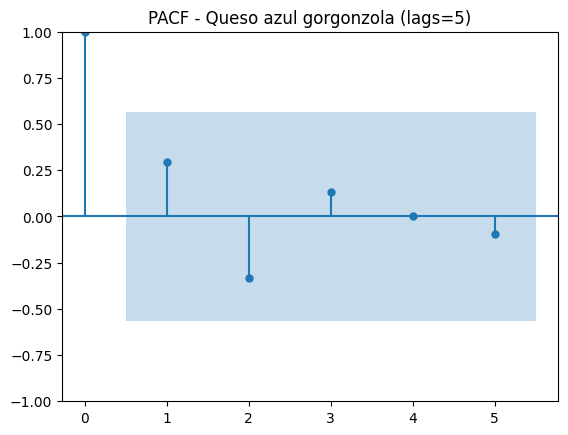


=== Producto: Queso azul roquefort | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

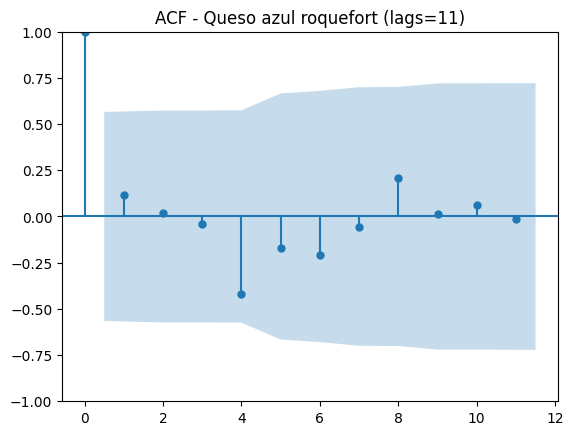

<Figure size 1000x400 with 0 Axes>

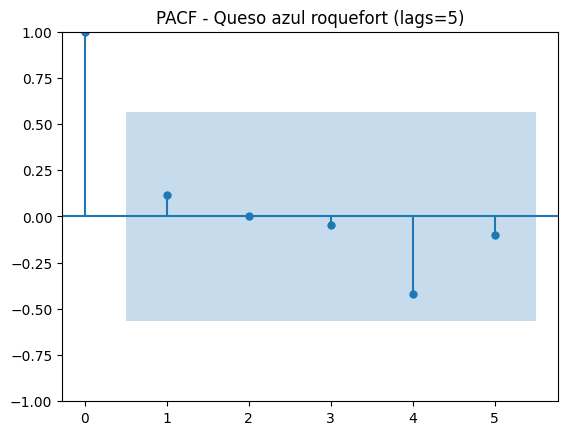


=== Producto: Queso blanco | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

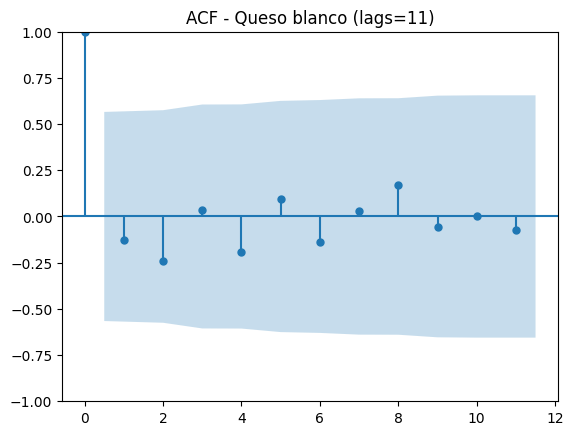

<Figure size 1000x400 with 0 Axes>

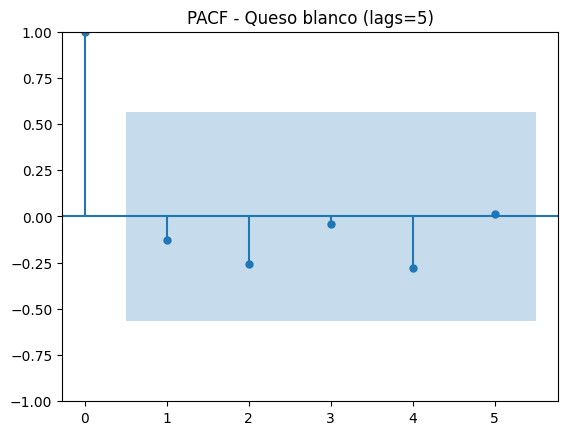


=== Producto: Queso brie | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

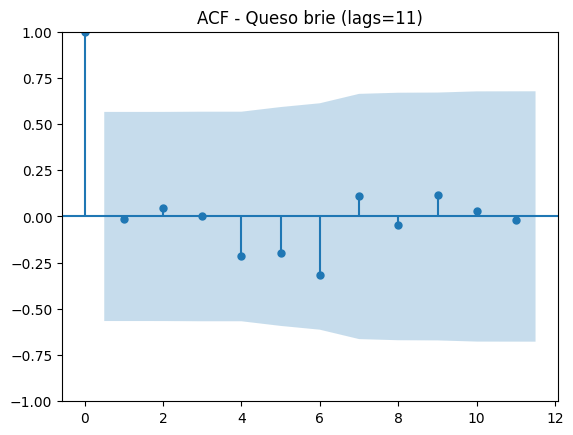

<Figure size 1000x400 with 0 Axes>

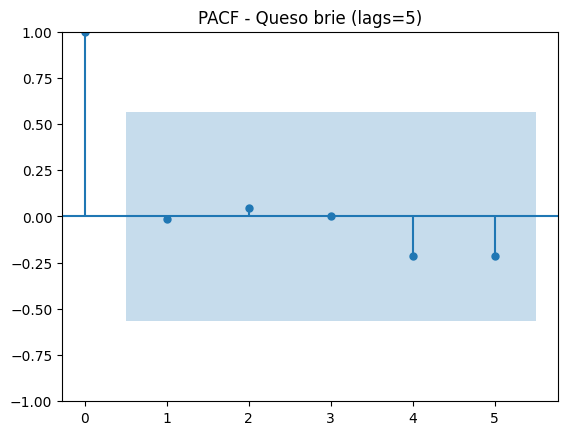


=== Producto: Queso camembert | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

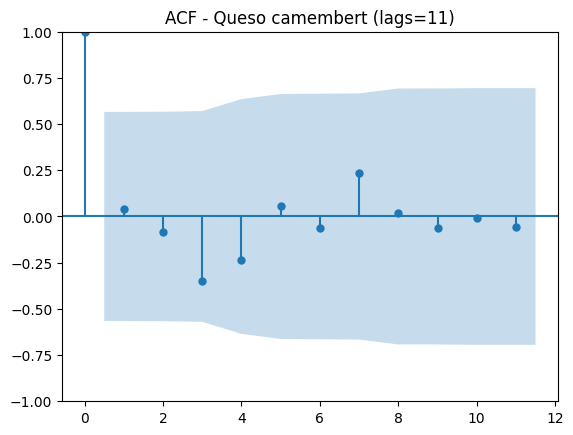

<Figure size 1000x400 with 0 Axes>

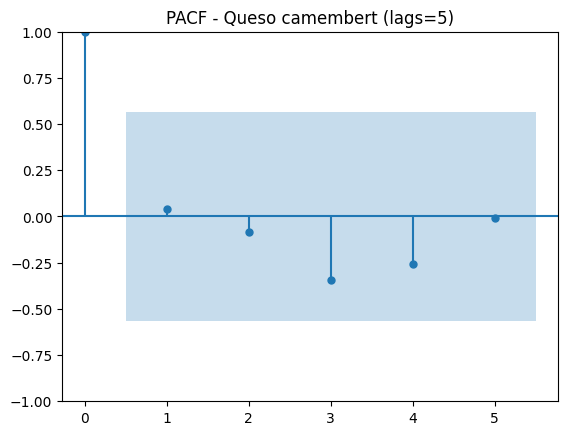


=== Producto: Queso cheddar añejo | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

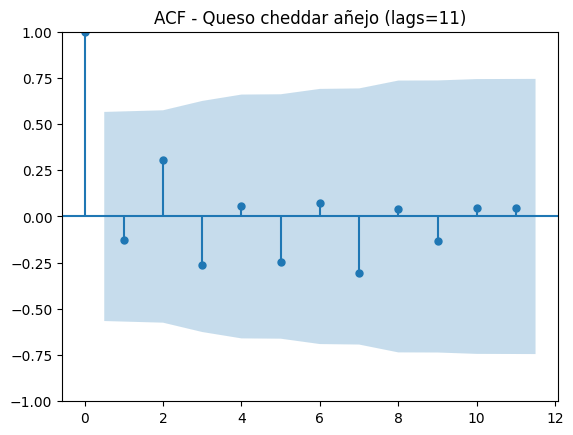

<Figure size 1000x400 with 0 Axes>

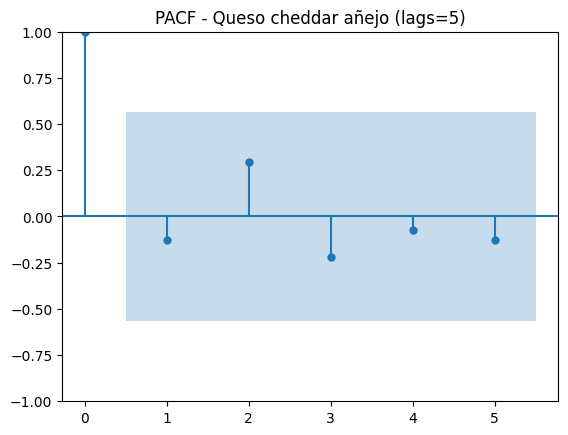


=== Producto: Queso edam | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

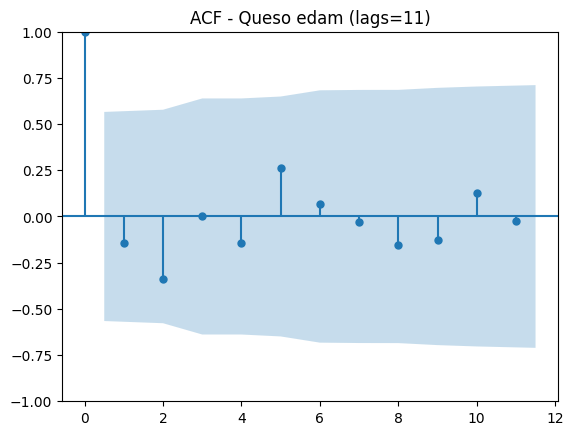

<Figure size 1000x400 with 0 Axes>

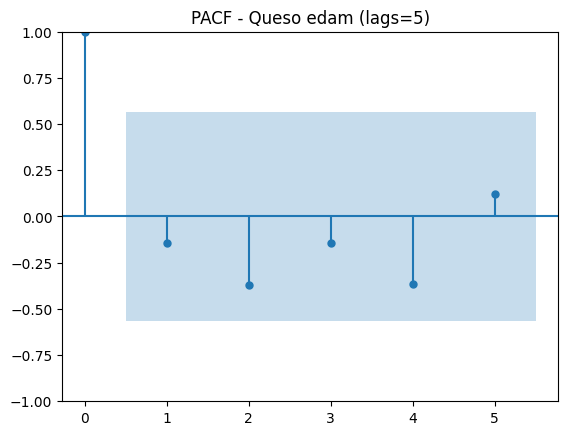


=== Producto: Queso en lonchas | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

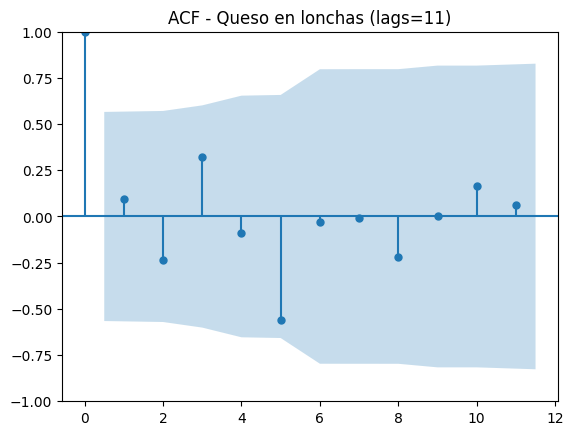

<Figure size 1000x400 with 0 Axes>

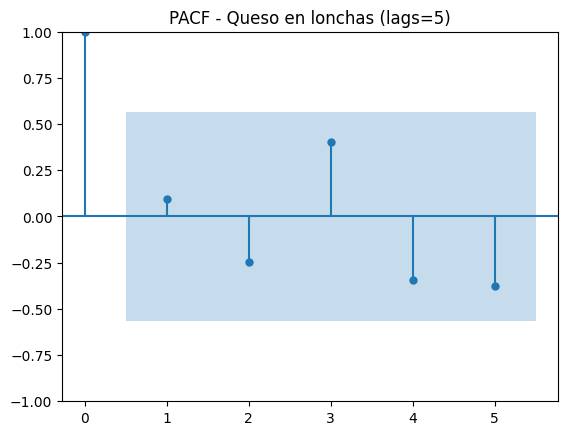


=== Producto: Queso gouda | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

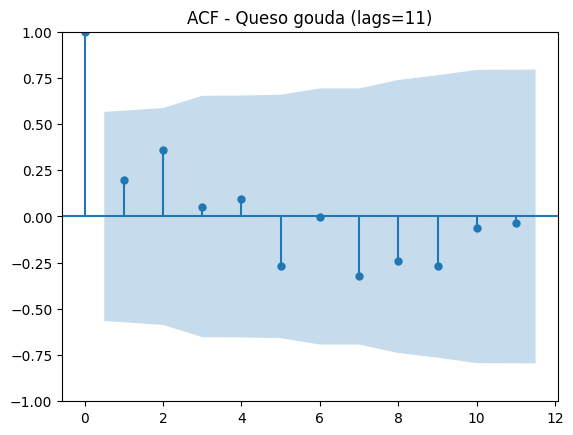

<Figure size 1000x400 with 0 Axes>

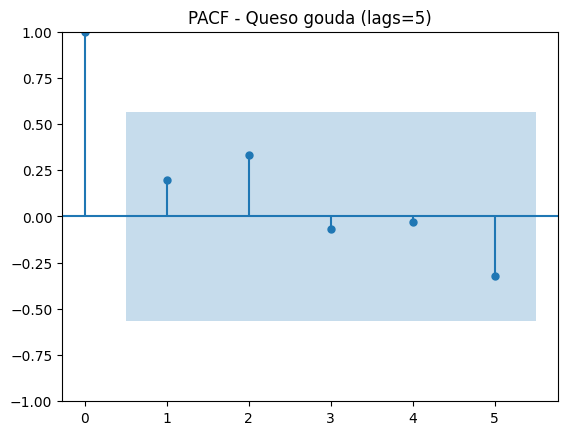


=== Producto: Queso gruyere | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

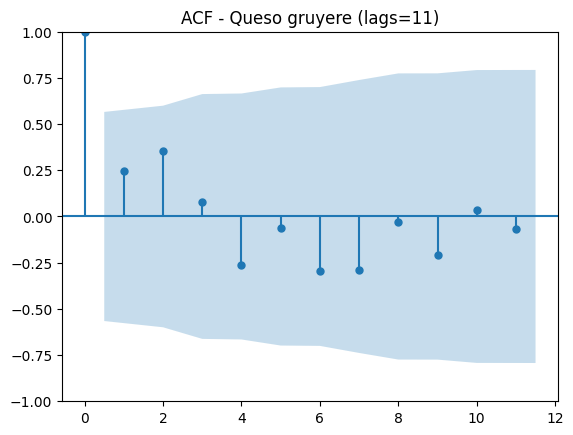

<Figure size 1000x400 with 0 Axes>

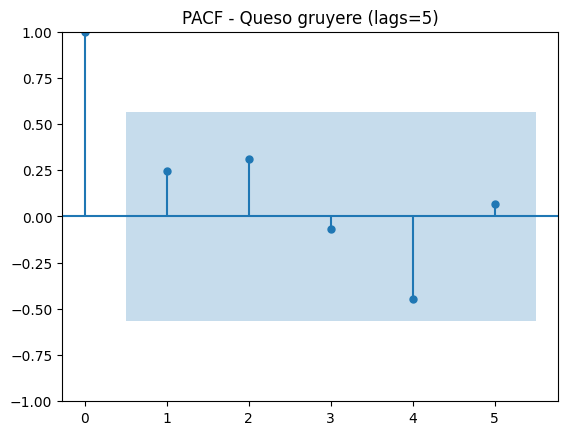


=== Producto: Queso havarti | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

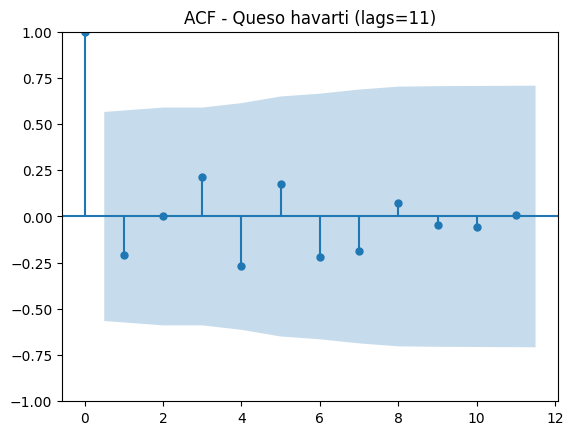

<Figure size 1000x400 with 0 Axes>

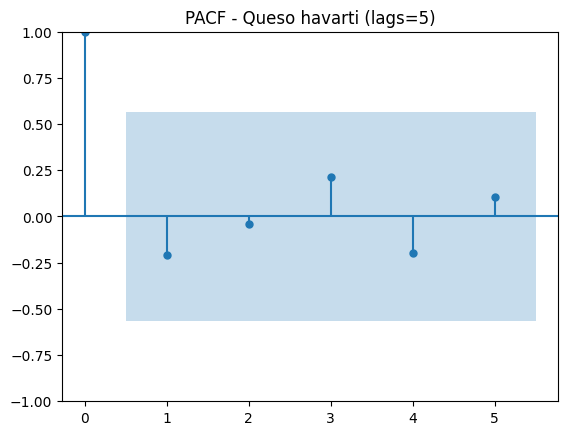


=== Producto: Queso mozzarella | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

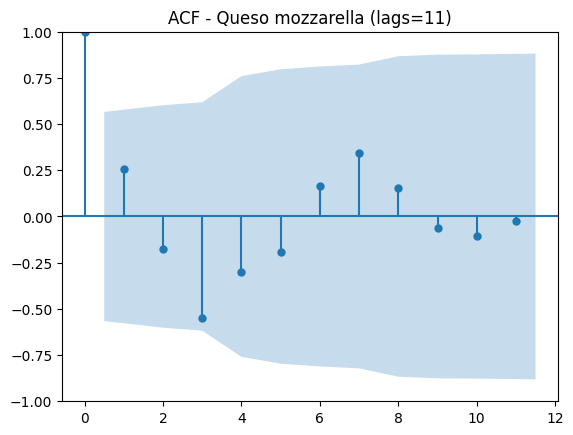

<Figure size 1000x400 with 0 Axes>

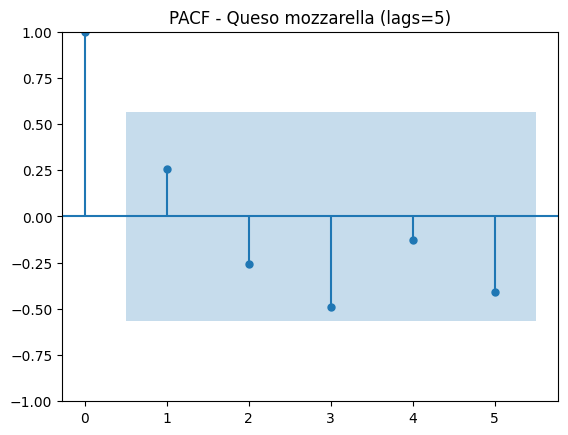


=== Producto: Queso para untar | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

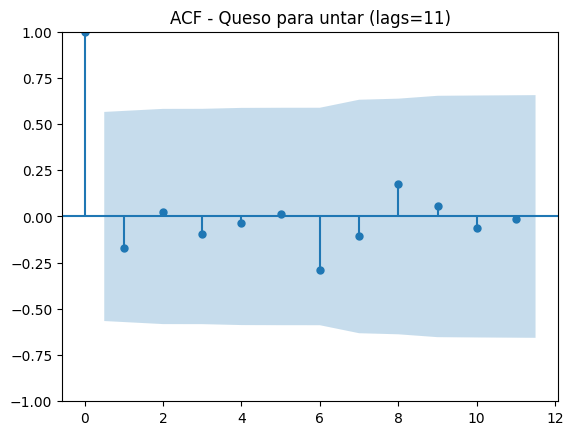

<Figure size 1000x400 with 0 Axes>

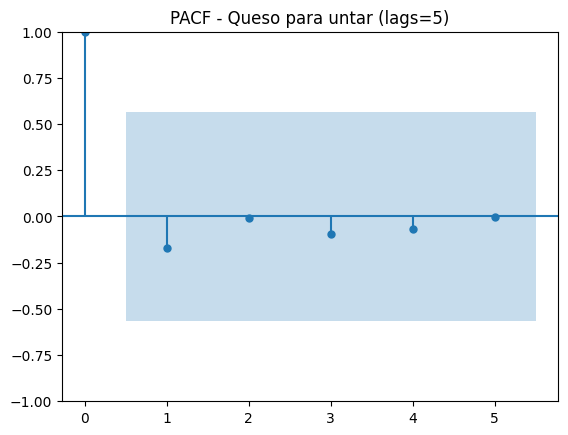


=== Producto: Queso parmesano | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

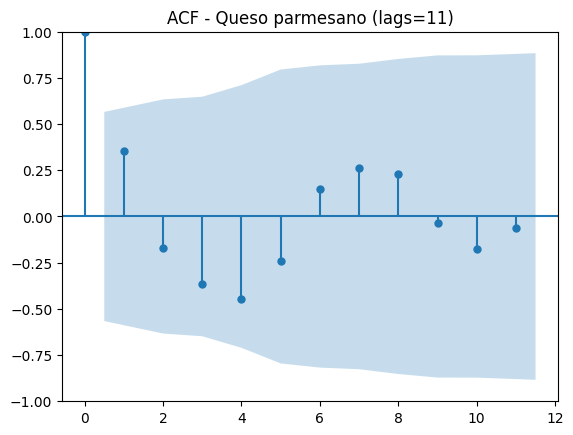

<Figure size 1000x400 with 0 Axes>

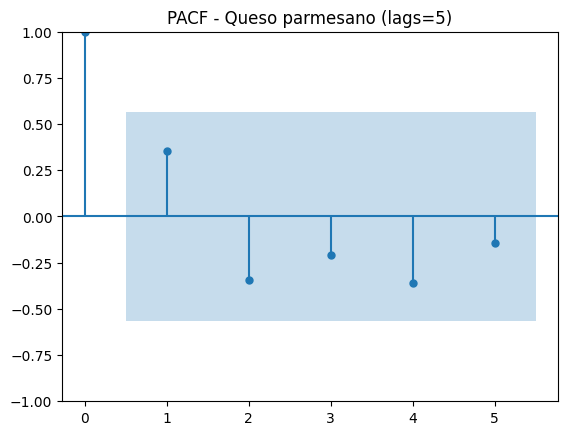


=== Producto: Queso ricota | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

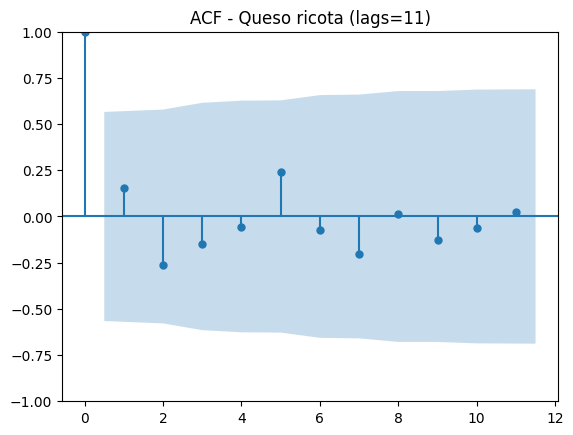

<Figure size 1000x400 with 0 Axes>

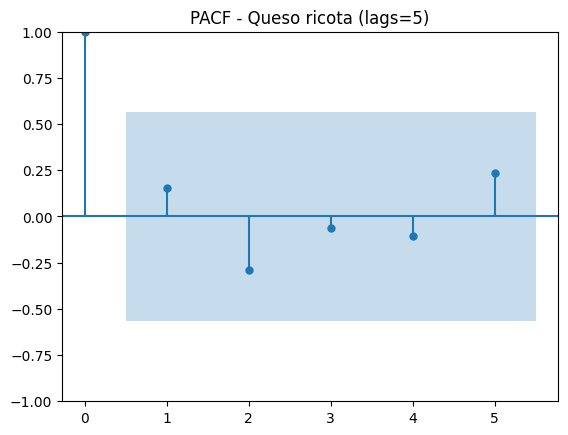


=== Producto: Kumis | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

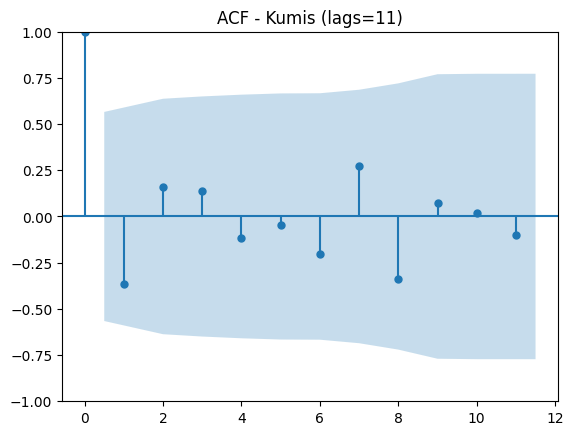

<Figure size 1000x400 with 0 Axes>

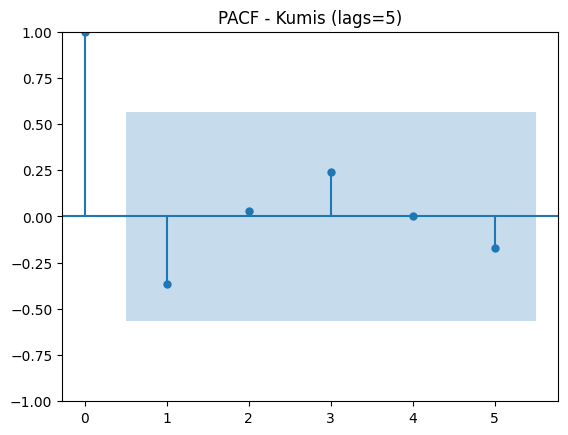


=== Producto: Yogur con frutas | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

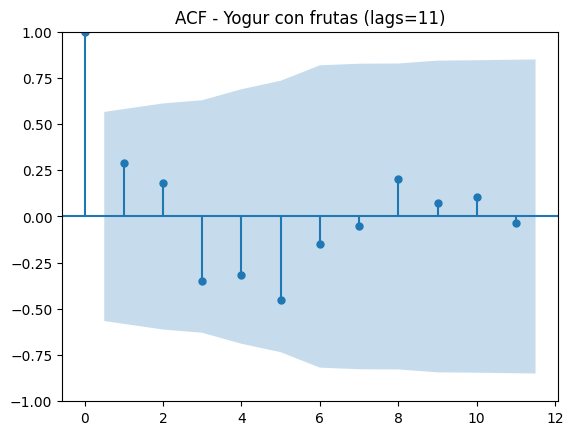

<Figure size 1000x400 with 0 Axes>

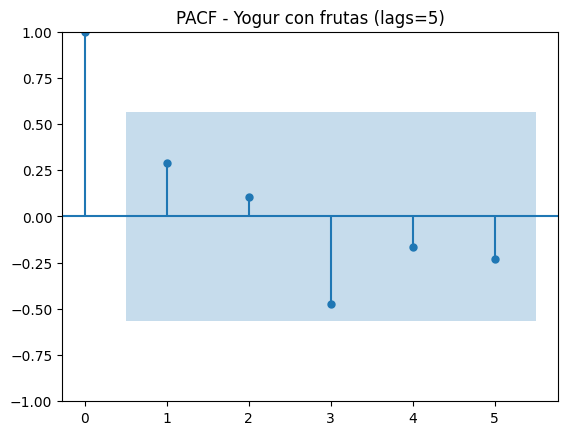


=== Producto: Yogur griego | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

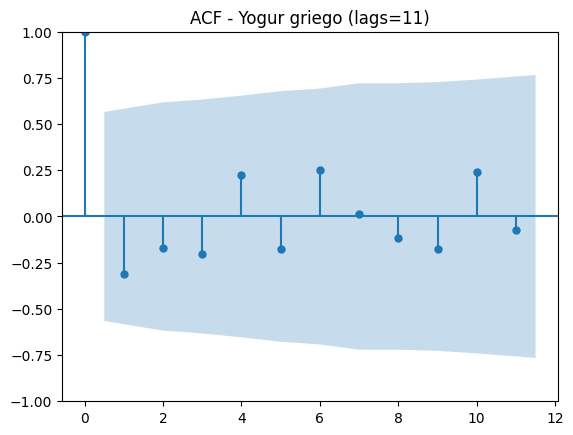

<Figure size 1000x400 with 0 Axes>

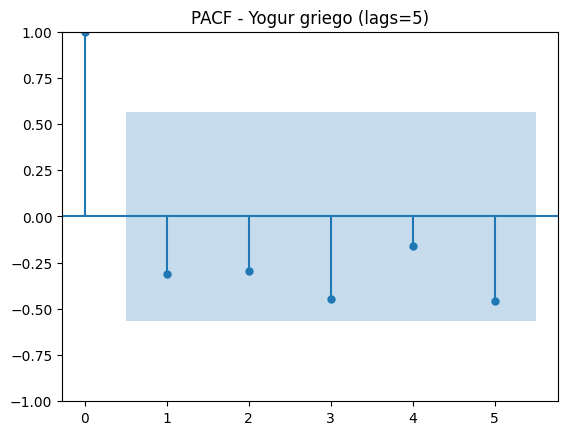


=== Producto: Yogur natural | nº observaciones: 12 ===


<Figure size 1000x400 with 0 Axes>

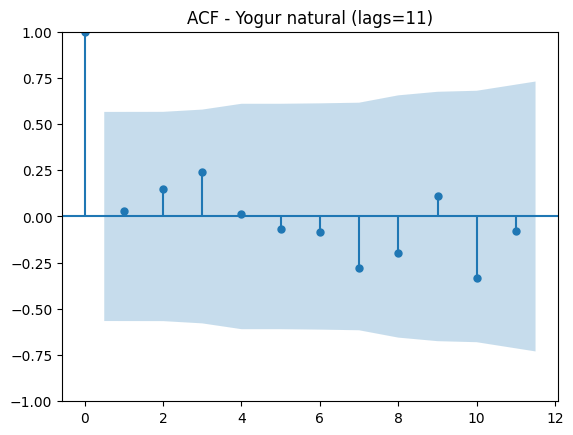

<Figure size 1000x400 with 0 Axes>

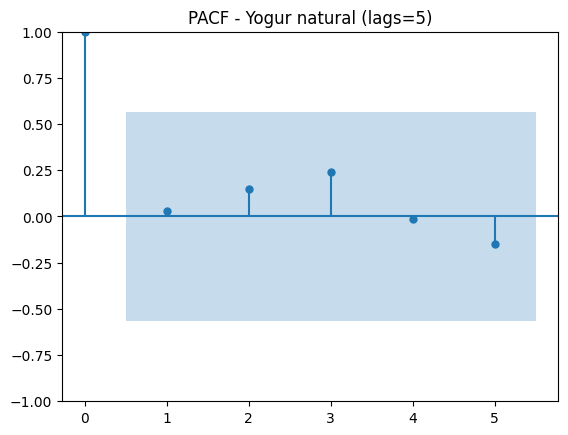

In [ ]:
ruta_acf = os.path.join(os.path.dirname(os.getcwd()), 'results', 'figures', 'acf')
ruta_pacf = os.path.join(os.path.dirname(os.getcwd()), 'results', 'figures', 'pacf')
os.makedirs(ruta_acf, exist_ok=True)
os.makedirs(ruta_pacf, exist_ok=True)

products = df_mensual["Producto"].unique()

for prod in products:
    sub = df_mensual[df_mensual["Producto"] == prod]

    serie = (
        sub.groupby("Fecha_mes")["Cantidad_mensual"]
        .sum()
        .asfreq("MS")
        .fillna(0)
    ).sort_index()

    n_obs = len(serie)
    print(f"\n=== Producto: {prod} | nº observaciones: {n_obs} ===")

    if n_obs < 3:
        print("Serie demasiado corta, se omite ACF/PACF.")
        continue

    max_lags_acf = min(24, n_obs - 1)

    plt.figure(figsize=(10, 4))
    plot_acf(serie, lags=max_lags_acf)
    plt.title(f"ACF - {prod} (lags={max_lags_acf})")
    nombre_acf = f"ACF_{prod}.png".replace(" ", "_").replace("/", "-")
    plt.savefig(os.path.join(ruta_acf, nombre_acf), dpi=150, bbox_inches="tight")
    plt.show()

    max_lags_pacf = min(24, n_obs // 2 - 1)

    if max_lags_pacf < 1:
        print("⚠ No se puede calcular PACF: nº de lags permitido < 1.")
        continue

    try:
        plt.figure(figsize=(10, 4))
        plot_pacf(serie, lags=max_lags_pacf, method="ywm")
        plt.title(f"PACF - {prod} (lags={max_lags_pacf})")
        nombre_pacf = f"PACF_{prod}.png".replace(" ", "_").replace("/", "-")
        plt.savefig(os.path.join(ruta_pacf, nombre_pacf), dpi=150, bbox_inches="tight")
        plt.show()
    except ValueError as e:
        print(f"⚠ Error calculando PACF para {prod}: {e}")
        continue

El análisis conjunto de las funciones de autocorrelación (ACF) para todos los productos lácteos parece indicar que, las series presentan cierto comportamiento estacionario, ya que no se observan decamientos lentos y persistentes. Hay cierto patrón oscilatorio en torno a los lags 4-7, lo que podría apuntar a ciclos de media duración comunes a varias categorías. 

En cuanto a las gráficas del PACF, nos puede sugerir que la alternancia de signos en los primeros lags y la significancia limitada a los primeros retardos sugieren la presencia de raíces complejas y, por tanto, un comportamiento cíclico de corto plazo coherente con lo observado en la ACF.

### 9. Análisis Bivariante

Se analiza la correlación entre el precio unitario y la cantidad comprada para evaluar si existe una relación lineal entre ambas variables y detectar posibles patrones de sensibilidad al precio. Este análisis permite comprobar si el comportamiento observado sigue la lógica económica de la demanda (variaciones en el precio asociadas a cambios en el volumen de compra) y valorar si el precio es un factor relevante para explicar las ventas

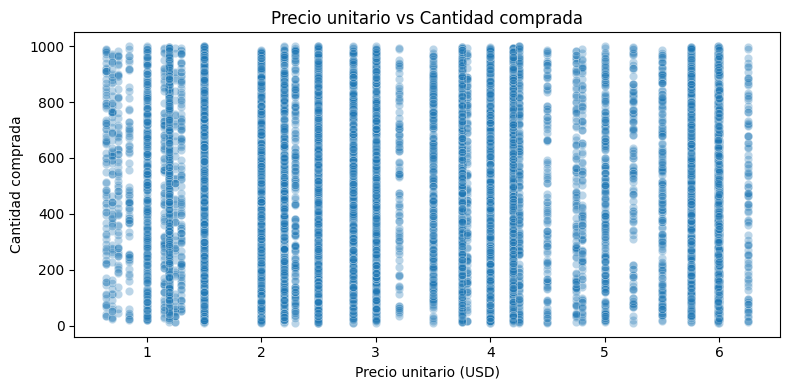

Correlación de Pearson:
                       Precio unitario (USD)  Cantidad comprada
Precio unitario (USD)               1.000000          -0.000058
Cantidad comprada                  -0.000058           1.000000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df, x="Precio unitario (USD)", y="Cantidad comprada", alpha=0.3, ax=ax)
ax.set_title("Precio unitario vs Cantidad comprada")
plt.tight_layout()
plt.show()

print("Correlación de Pearson:")
print(df[["Precio unitario (USD)", "Cantidad comprada"]].corr())

No existe relación lineal significativa entre el precio unitario y la cantidad comprada en el dataset analizado.

### 10. Conclusiones

El análisis exploratorio realizado confirma que el dataset presenta una calidad suficiente en términos estructurales: no hay valores nulos, no existen series temporales incompletas y todas las combinaciones Producto+Presentación cuentan con histórico para los 12 meses del año. Sin embargo, este volumen de datos es insuficiente para entrenar un modelo predictivo robusto: cada combinación Producto+Presentación dispone únicamente de 12 observaciones mensuales, muy por debajo de lo que requeriría un modelo de machine learning como CatBoost para aprender patrones de demanda fiables. En un contexto real sería necesario contar con varios años de histórico. No obstante, con fines de aprendizaje, se llevará a cabo la construcción de un modelo CatBoost sobre esta estructura, tomando cantidad_total_mes como variable objetivo, con el propósito de familiarizarse con el flujo completo de un proyecto de predicción de demanda

> **Nota:** La elección de CatBoost responde al propósito de práctica del proyecto. Para un dataset de este tamaño (441 filas, 9 meses por serie), modelos más sencillos como ARIMA, pensado específicamente para series temporales, o una regresión lineal probablemente serían más apropiados, con menor riesgo de sobreajuste y más fáciles de interpretar.